# Analyse des pseudo-labels MEB — TextureSAM
Exploration des embeddings extraits de l'encodeur image SAM2 sur les patches annotés par PatchTagger.

In [1]:
# ── Cell 1 — Setup ──────────────────────────────────────────────────────────
import os, sys, time, warnings, zipfile, tempfile
import numpy as np
import torch
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from pathlib import Path
from PIL import Image
import pandas as pd
import json
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score
import ipywidgets as widgets
from IPython.display import display, clear_output
from tqdm.notebook import tqdm
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 110, 'figure.facecolor': 'white'})

# ── Chemins ─────────────────────────────────────────────────────────────────
ROOT          = Path('..').resolve()
SAM2_DIR      = ROOT / 'TextureSAM' / 'sam2'
IMG_DIR       = ROOT / 'Image_Ouassim'
PATCH_DIR     = ROOT / 'PatchTagger_Output' / 'patches'
CONFIG_JSON   = ROOT / 'PatchTagger_Output' / 'config' / 'config.json'
CATEGORIES_XL = ROOT / 'PatchTagger_Output' / 'categories.xlsx'
MAPPING_XL    = ROOT / 'PatchTagger_Output' / 'mapping.xlsx'
CKPT_PATH     = ROOT / 'checkpoints' / 'sam2.1_hiera_small_1.pt'

if str(SAM2_DIR) not in sys.path:
    sys.path.insert(0, str(SAM2_DIR))

# ── Constantes ──────────────────────────────────────────────────────────────
SEED         = 42
IMG_SIZE     = 1024
PATCH_ORIG   = 128
STAGE3_SIZE  = 64

STAGE_NAMES  = ['Stage 1', 'Stage 2', 'Stage 3', 'Stage 4']
CONV_IDX     = {'Stage 1': 3, 'Stage 2': 2, 'Stage 3': 1, 'Stage 4': 0}
STAGE_SIZES  = {'Stage 1': 256, 'Stage 2': 128, 'Stage 3': 64, 'Stage 4': 32}

# SAM normalisation
_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
_STD  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

np.random.seed(SEED)
torch.manual_seed(SEED)

# ── État global ──────────────────────────────────────────────────────────────
STATE = {
    'model'      : None,
    'features'   : {},
    'categories' : {},
    'dataset'    : None,
    'embeddings' : {}
}

print('Imports OK')
print(f'ROOT     : {ROOT}')
print(f'IMG_DIR  : {IMG_DIR}')
print(f'CKPT     : {CKPT_PATH.name}')
print(f'Device   : {"cuda" if torch.cuda.is_available() else "cpu"}')

Imports OK
ROOT     : /home/aidouni/meb_texture_seg
IMG_DIR  : /home/aidouni/meb_texture_seg/Image_Ouassim
CKPT     : sam2.1_hiera_small_1.pt
Device   : cuda


In [2]:
# ── Cell 2 — Chargement des métadonnées ─────────────────────────────────────

CATEGORIES_TEST = [1, 3, 4, 5, 6, 7, 9]

CATEGORIES_NAMES = {
    1 : 'Totalement homogène',
    3 : 'Faisceaux',
    4 : 'Filaments',
    5 : 'Stratifié rectiligne',
    6 : 'Stratifié sinueux',
    7 : 'Granuleux',
    9 : 'Trou',
}

def load_metadata():
    # ── A. Lire config.json ──────────────────────────────────────────────────
    with open(CONFIG_JSON) as f:
        cfg = json.load(f)

    CATEGORIES = {}
    for k, v in cfg['available_categories'].items():
        CATEGORIES[int(k)] = {'name': v['name'], 'color': v['color']}
    STATE['categories'] = CATEGORIES

    # ── B. Lire categories.xlsx et filtrer sur CATEGORIES_TEST ───────────────
    df = pd.read_excel(CATEGORIES_XL)
    df = df[df['category'].isin(CATEGORIES_TEST)].copy()
    df = df.reset_index(drop=True)
    STATE['dataset'] = df

    # ── C. Construire l'index par image ──────────────────────────────────────
    image_index = {}
    for _, row in df.iterrows():
        img_name = row['Image_name']
        if img_name not in image_index:
            image_index[img_name] = []
        cat_id = int(row['category'])
        image_index[img_name].append({
            # L'outil annotation stocke x=row(0-768), y=col(0-1280)
            # → on remet en convention image : x=col (horizontal), y=row (vertical)
            'x_min'   : int(row['y_min']),
            'x_max'   : int(row['y_max']),
            'y_min'   : int(row['x_min']),
            'y_max'   : int(row['x_max']),
            'category': cat_id,
            'cat_name': CATEGORIES[cat_id]['name']
        })

    STATE['image_index'] = image_index
    return image_index


image_index = load_metadata()
df = STATE['dataset']
CATEGORIES = STATE['categories']

# ── Affichage ────────────────────────────────────────────────────────────────
print(f'Images avec annotations retenues : {len(image_index)}')
print()
print("Catégories retenues pour l'analyse :")
print()
total = len(df)
counts = df['category'].value_counts().sort_index()

header = f'{"Cat":<5} {"Nom":<24} {"Count":>6}   %'
sep    = '─' * 46
print(header)
print(sep)
for cat_id in CATEGORIES_TEST:
    n    = counts.get(cat_id, 0)
    name = CATEGORIES_NAMES[cat_id]
    pct  = 100 * n / total if total > 0 else 0
    print(f'{cat_id:<5} {name:<24} {n:>6}   {pct:.1f}%')
print(sep)
print(f'{"":<5} {"Total":<24} {total:>6}')
print()
print(f'Baseline NN aléatoire = 1/{len(CATEGORIES_TEST)} = {100/len(CATEGORIES_TEST):.1f}%')
print()

# Warning si < 30 patches
for cat_id in CATEGORIES_TEST:
    n = counts.get(cat_id, 0)
    if n < 30:
        name = CATEGORIES_NAMES[cat_id]
        print(f'⚠️  Cat {cat_id} ({name}) : seulement {n} patches → résultats peu fiables')


Images avec annotations retenues : 43

Catégories retenues pour l'analyse :

Cat   Nom                       Count   %
──────────────────────────────────────────────
1     Totalement homogène          42   5.0%
3     Faisceaux                    87   10.3%
4     Filaments                    49   5.8%
5     Stratifié rectiligne         64   7.6%
6     Stratifié sinueux           129   15.3%
7     Granuleux                   410   48.7%
9     Trou                         61   7.2%
──────────────────────────────────────────────
      Total                       842

Baseline NN aléatoire = 1/7 = 14.3%



In [3]:
# ── Cell 3 — Chargement du modèle ────────────────────────────────────────────

def _build_encoder():
    from sam2.modeling.backbones.hieradet import Hiera
    from sam2.modeling.backbones.image_encoder import ImageEncoder, FpnNeck
    from sam2.modeling.position_encoding import PositionEmbeddingSine
    trunk = Hiera(
        embed_dim=96, num_heads=1, stages=(1, 2, 11, 2),
        global_att_blocks=(7, 10, 13),
        window_pos_embed_bkg_spatial_size=(7, 7)
    )
    neck = FpnNeck(
        position_encoding=PositionEmbeddingSine(
            num_pos_feats=256, normalize=True, scale=None, temperature=10000),
        d_model=256, backbone_channel_list=[768, 384, 192, 96],
        kernel_size=1, stride=1, padding=0,
        fpn_interp_model='nearest', fuse_type='sum', fpn_top_down_levels=[2, 3]
    )
    return ImageEncoder(trunk=trunk, neck=neck, scalp=1)


def _load_ckpt():
    ckpt_pt  = CKPT_PATH
    ckpt_dir = ROOT / 'checkpoints' / 'sam2.1_hiera_small_1'
    if ckpt_pt.is_file():
        try:
            sd = torch.load(ckpt_pt, map_location='cpu', weights_only=True)
            return sd.get('model', sd)
        except Exception:
            pass
    archive = ckpt_dir / 'archive' if (ckpt_dir / 'archive').is_dir() else ckpt_dir
    if archive.is_dir():
        with tempfile.NamedTemporaryFile(suffix='.pt', delete=False) as tmp:
            tmp_path = tmp.name
        with zipfile.ZipFile(tmp_path, 'w', zipfile.ZIP_STORED) as zf:
            for fp in sorted(archive.rglob('*')):
                if fp.is_file():
                    info = zipfile.ZipInfo(str(fp.relative_to(archive.parent)))
                    info.date_time = (1980, 1, 1, 0, 0, 0)
                    zf.writestr(info, fp.read_bytes())
        sd = torch.load(tmp_path, map_location='cpu', weights_only=False)
        os.unlink(tmp_path)
        return sd.get('model', sd)
    return None


device  = 'cuda' if torch.cuda.is_available() else 'cpu'
encoder = _build_encoder()
sd      = _load_ckpt()

if sd is not None:
    prefix = 'image_encoder.'
    if any(k.startswith(prefix) for k in sd):
        sd = {k[len(prefix):]: v for k, v in sd.items() if k.startswith(prefix)}
    miss, unex = encoder.load_state_dict(sd, strict=False)
    print(f'Checkpoint chargé ({len(miss)} manquantes, {len(unex)} inattendues)')
else:
    print('⚠️  Poids aléatoires — checkpoint non trouvé')

encoder = encoder.to(device).eval()
STATE['model'] = encoder
print(f'Modèle chargé ✅  (device={device})')

# ── Enregistrement des hooks permanents ─────────────────────────────────────
_hooks = []

def _make_hook(stage_name):
    def _hook(module, inp, out):
        STATE['features'][stage_name] = out.detach()
    return _hook

for sn, ci in CONV_IDX.items():
    h = encoder.neck.convs[ci].register_forward_hook(_make_hook(sn))
    _hooks.append(h)

print('Hooks enregistrés ✅')
print(f'  Stages hookés : {list(CONV_IDX.keys())}')

Checkpoint chargé (0 manquantes, 0 inattendues)
Modèle chargé ✅  (device=cuda)
Hooks enregistrés ✅
  Stages hookés : ['Stage 1', 'Stage 2', 'Stage 3', 'Stage 4']


In [4]:
# ── Cell 4 — Fonctions d'extraction ─────────────────────────────────────────

print('=== Vérifications ===')
sx_check = IMG_SIZE / 1280
sy_check = IMG_SIZE / 768
stride   = IMG_SIZE / STAGE3_SIZE       # = 16 pixels/vecteur
w_feat   = PATCH_ORIG * sx_check / stride
h_feat   = PATCH_ORIG * sy_check / stride
print(f'Image 1280×768 → resize {IMG_SIZE}×{IMG_SIZE} :')
print(f'  scale_x = {IMG_SIZE}/1280 = {sx_check:.3f}')
print(f'  scale_y = {IMG_SIZE}/768  = {sy_check:.3f}')
print()
print(f'Stage 3 feature map {STAGE3_SIZE}×{STAGE3_SIZE} :')
print(f'  chaque vecteur couvre {int(stride)}×{int(stride)} pixels')
print(f'  d\'une image {IMG_SIZE}×{IMG_SIZE}')
print()
print(f'Un patch {PATCH_ORIG}×{PATCH_ORIG} en Stage 3 :')
print(f'  largeur en feature map = {PATCH_ORIG} × {sx_check:.3f} / {int(stride)} = {w_feat:.1f} ≈ {int(w_feat)} vecteurs')
print(f'  hauteur en feature map = {PATCH_ORIG} × {sy_check:.3f} / {int(stride)} = {h_feat:.1f} ≈ {int(h_feat)} vecteurs')
print(f'  total ≈ {int(w_feat) * int(h_feat)} vecteurs dans le patch ✅')
print()
print('Mode L → RGB : réplication canal ✅')
print()


# ── Prétraitement ────────────────────────────────────────────────────────────
def preprocess_image(img_path):
    img  = Image.open(img_path).convert('L')
    orig_w, orig_h = img.size          # 1280, 768
    img_rgb = Image.merge('RGB', [img, img, img])
    img_rgb = img_rgb.resize((IMG_SIZE, IMG_SIZE), Image.BILINEAR)
    x = torch.from_numpy(np.array(img_rgb)).float() / 255.0
    x = x.permute(2, 0, 1)             # (3, H, W)
    x = (x - _MEAN) / _STD
    sx = IMG_SIZE / orig_w             # 1024/1280 = 0.800
    sy = IMG_SIZE / orig_h             # 1024/768  = 1.333
    return x.unsqueeze(0).to(device), sx, sy


# ── Extraction des features pour une image ───────────────────────────────────
def extract_features(img_path):
    tensor, sx, sy = preprocess_image(img_path)
    with torch.no_grad():
        encoder(tensor)
    # Les hooks ont rempli STATE['features']
    result = {}
    for sn in STAGE_NAMES:
        # shape: (1, 256, H, W)  →  numpy (H, W, 256)
        result[sn] = STATE['features'][sn][0].permute(1, 2, 0).cpu().numpy()
    return result, sx, sy


# ── Mapping coordonnées patch → feature map ──────────────────────────────────
def patch_to_feature_coords(x_min, y_min, x_max, y_max, sx, sy, stage_size):
    stride_feat = IMG_SIZE / stage_size
    fx1 = int(x_min * sx / stride_feat)
    fy1 = int(y_min * sy / stride_feat)
    fx2 = int(x_max * sx / stride_feat)
    fy2 = int(y_max * sy / stride_feat)
    # Clamp aux dimensions de la feature map
    fx1 = max(0, min(fx1, stage_size - 1))
    fy1 = max(0, min(fy1, stage_size - 1))
    fx2 = max(fx1 + 1, min(fx2, stage_size))
    fy2 = max(fy1 + 1, min(fy2, stage_size))
    return fx1, fy1, fx2, fy2


# ── Embedding d'un patch ─────────────────────────────────────────────────────
def get_patch_embedding(feature_map, fx1, fy1, fx2, fy2):
    """
    feature_map : np.ndarray (H, W, 256)
    Retourne vecteur 256d normalisé L2.
    """
    H, W, C = feature_map.shape
    if fx1 >= W or fy1 >= H or fx2 <= 0 or fy2 <= 0:
        return None
    region = feature_map[fy1:fy2, fx1:fx2, :]  # (h, w, 256)
    if region.size == 0:
        return None
    vec  = region.reshape(-1, C).mean(axis=0)   # (256,)
    norm = np.linalg.norm(vec)
    if norm < 1e-8:
        return None
    return vec / norm


# ── Test sur la première image annotée ───────────────────────────────────────
img_index = STATE.get('image_index', {})
test_name  = sorted(img_index.keys())[0]
test_path  = IMG_DIR / test_name
test_patch = img_index[test_name][0]

feats, sx, sy = extract_features(test_path)
stage3_feat   = feats['Stage 3']

p = test_patch
fx1, fy1, fx2, fy2 = patch_to_feature_coords(
    p['x_min'], p['y_min'], p['x_max'], p['y_max'],
    sx, sy, STAGE3_SIZE
)
emb = get_patch_embedding(stage3_feat, fx1, fy1, fx2, fy2)

n_vecs = (fx2 - fx1) * (fy2 - fy1)
print(f'Image : {test_name}')
print(f'Patch  (x_min={p["x_min"]}, y_min={p["y_min"]},'
      f' x_max={p["x_max"]}, y_max={p["y_max"]})')
print(f'Scale  : sx={sx:.3f}, sy={sy:.3f}')
print(f'En Stage 3 ({STAGE3_SIZE}×{STAGE3_SIZE}) :')
print(f'  feat_coords = ({fx1}, {fy1}, {fx2}, {fy2})')
print(f'  nb vecteurs dans le patch : {n_vecs}')
if emb is not None:
    print(f'  embedding shape : {emb.shape}')
    print(f'  embedding norm  : {np.linalg.norm(emb):.4f} ✅')
else:
    print('  ⚠️  embedding None — patch hors limites')

=== Vérifications ===
Image 1280×768 → resize 1024×1024 :
  scale_x = 1024/1280 = 0.800
  scale_y = 1024/768  = 1.333

Stage 3 feature map 64×64 :
  chaque vecteur couvre 16×16 pixels
  d'une image 1024×1024

Un patch 128×128 en Stage 3 :
  largeur en feature map = 128 × 0.800 / 16 = 6.4 ≈ 6 vecteurs
  hauteur en feature map = 128 × 1.333 / 16 = 10.7 ≈ 10 vecteurs
  total ≈ 60 vecteurs dans le patch ✅

Mode L → RGB : réplication canal ✅

Image : 060525-JPB-MEB-EIHNValves-Ech1-ZigZag20002.tif
Patch  (x_min=128, y_min=0, x_max=256, y_max=128)
Scale  : sx=0.800, sy=1.333
En Stage 3 (64×64) :
  feat_coords = (6, 0, 12, 10)
  nb vecteurs dans le patch : 60
  embedding shape : (256,)
  embedding norm  : 1.0000 ✅


In [ ]:
# ── Cell 4b — Vérification visuelle de patch_to_feature_coords ───────────────
#
# Pour chaque patch annoté sur l'image test :
#   - Gauche  : image originale  + rectangle rouge du patch
#   - Droite  : PCA RGB Stage 3  + rectangle rouge de la région feature
#
# Si les rectangles sont au même endroit relatif → formule correcte ✅

MAX_PATCHES_SHOW = 6

def _pca_rgb_local(feat_hw256):
    """(H, W, 256) → rgb (H, W, 3) normalisé [0,1]"""
    H, W, C = feat_hw256.shape
    X   = feat_hw256.reshape(-1, C).astype(np.float32)
    pca = PCA(n_components=3, random_state=SEED)
    pcs = pca.fit_transform(X).reshape(H, W, 3)
    for i in range(3):
        lo, hi = pcs[:, :, i].min(), pcs[:, :, i].max()
        if hi - lo > 1e-8:
            pcs[:, :, i] = (pcs[:, :, i] - lo) / (hi - lo)
    return pcs


img_index = STATE.get('image_index', {})
test_name  = sorted(img_index.keys())[0]
test_path  = IMG_DIR / test_name

feats, sx, sy = extract_features(test_path)
img_pil  = Image.open(test_path).convert('L')
img_arr  = np.array(img_pil)
orig_h, orig_w = img_arr.shape         # 768, 1280

pca_rgb = _pca_rgb_local(feats['Stage 3'])   # (64, 64, 3)
pca_up  = np.array(
    Image.fromarray((pca_rgb * 255).astype(np.uint8)).resize(
        (orig_w, orig_h), Image.NEAREST   # NEAREST : blocs visibles
    )
) / 255.0

patches   = img_index[test_name][:MAX_PATCHES_SHOW]
n_patches = len(patches)

fig, axes = plt.subplots(n_patches, 2, figsize=(12, 3 * n_patches))
if n_patches == 1:
    axes = axes[None, :]

for row, patch in enumerate(patches):
    x1, y1 = patch['x_min'], patch['y_min']   # x = horizontal, y = vertical
    x2, y2 = patch['x_max'], patch['y_max']
    cat     = patch['category']

    sz = STAGE3_SIZE
    fx1, fy1, fx2, fy2 = patch_to_feature_coords(x1, y1, x2, y2, sx, sy, sz)

    # coordonnées feature ramenées dans l'espace upsamplé
    ux1 = int(fx1 * orig_w / sz)
    uy1 = int(fy1 * orig_h / sz)
    uw  = int((fx2 - fx1) * orig_w / sz)
    uh  = int((fy2 - fy1) * orig_h / sz)

    ax0 = axes[row, 0]
    ax0.imshow(img_arr, cmap='gray')
    ax0.add_patch(mpatches.Rectangle(
        (x1, y1), x2 - x1, y2 - y1,
        lw=2, edgecolor='red', facecolor='red', alpha=0.35
    ))
    ax0.set_aspect('auto'); ax0.axis('off')
    ax0.set_title(
        f'Original  ({x1},{y1})→({x2},{y2})\n{CATEGORIES_NAMES[cat]}', fontsize=8
    )

    ax1 = axes[row, 1]
    ax1.imshow(pca_up)
    ax1.add_patch(mpatches.Rectangle(
        (ux1, uy1), uw, uh,
        lw=2, edgecolor='red', facecolor='red', alpha=0.35
    ))
    ax1.set_aspect('auto'); ax1.axis('off')
    ax1.set_title(
        f'Stage 3 PCA  feat ({fx1},{fy1})→({fx2},{fy2}) / 64×64', fontsize=8
    )

plt.suptitle(
    f'{test_name}\nsx={sx:.3f}  sy={sy:.3f}  stride=16',
    fontsize=9
)
plt.tight_layout()
plt.show()
print('Zones rouges au même endroit relatif → formule correcte ✅')

In [5]:
# ── Cell 5 — Extraction globale ──────────────────────────────────────────────
# Pas de bouton/widget : exécution directe (évite toute duplication ipywidgets).

def run_extraction():
    img_index = STATE.get('image_index', {})
    if not img_index:
        print('Charger les métadonnées d\'abord (Cell 2).')
        return

    buffers = {sn: {'vectors': [], 'labels': [], 'img_ids': [], 'positions': []}
               for sn in STAGE_NAMES}

    img_names = sorted(img_index.keys())
    print('Extraction en cours...')

    t0 = time.time()
    for img_name in tqdm(img_names, desc='Images'):
        img_path = IMG_DIR / img_name
        if not img_path.exists():
            print(f'  ⚠️  {img_name} introuvable — ignoré')
            continue

        try:
            feats, sx, sy = extract_features(img_path)
        except Exception as e:
            print(f'  ⚠️  Erreur sur {img_name} : {e}')
            continue

        for patch in img_index[img_name]:
            cat = patch['category']
            x1, y1, x2, y2 = patch['x_min'], patch['y_min'], patch['x_max'], patch['y_max']

            for sn in STAGE_NAMES:
                sz  = STAGE_SIZES[sn]
                fx1, fy1, fx2, fy2 = patch_to_feature_coords(x1, y1, x2, y2, sx, sy, sz)
                emb = get_patch_embedding(feats[sn], fx1, fy1, fx2, fy2)
                if emb is None:
                    buffers[sn].setdefault('_skipped', 0)
                    buffers[sn]['_skipped'] += 1
                    continue
                buffers[sn]['vectors'].append(emb)
                buffers[sn]['labels'].append(cat)
                buffers[sn]['img_ids'].append(img_name)
                buffers[sn]['positions'].append([x1, y1, x2, y2])

    for sn in STAGE_NAMES:
        buf = buffers[sn]
        if buf['vectors']:
            STATE['embeddings'][sn] = {
                'vectors'  : np.array(buf['vectors'],   dtype=np.float32),
                'labels'   : np.array(buf['labels'],    dtype=np.int32),
                'img_ids'  : np.array(buf['img_ids']),
                'positions': np.array(buf['positions'], dtype=np.int32)
            }

    elapsed = time.time() - t0
    print(f'\nExtraction terminée en {elapsed:.1f}s')
    skipped_total = sum(buffers[sn].get('_skipped', 0) for sn in STAGE_NAMES)
    if skipped_total:
        print(f'  ({skipped_total} embeddings None ignorés — coordonnées hors feature map)')
    print()

    s3 = STATE['embeddings'].get('Stage 3', {})
    if s3:
        N = len(s3['vectors'])
        print(f'Stage 3 : {N} vecteurs extraits')
        print('Distribution :')
        labels = s3['labels']
        for cat_id in CATEGORIES_TEST:
            n    = int((labels == cat_id).sum())
            name = CATEGORIES_NAMES[cat_id]
            print(f'  {name:<22} ({cat_id:2d})  : {n} vecteurs')


run_extraction()

Extraction en cours...


Images:   0%|          | 0/43 [00:00<?, ?it/s]

  ⚠️  060722-Nabila-JP-Valves-WholeMount-SAureus-pat02-06.tif introuvable — ignoré

Extraction terminée en 3.3s

Stage 3 : 816 vecteurs extraits
Distribution :
  Totalement homogène    ( 1)  : 41 vecteurs
  Faisceaux              ( 3)  : 68 vecteurs
  Filaments              ( 4)  : 49 vecteurs
  Stratifié rectiligne   ( 5)  : 64 vecteurs
  Stratifié sinueux      ( 6)  : 129 vecteurs
  Granuleux              ( 7)  : 409 vecteurs
  Trou                   ( 9)  : 56 vecteurs


In [ ]:
# ── Cell 6 — PCA RGB sur une image ───────────────────────────────────────────
# Exécution directe (pas de dropdown/bouton).
# Pour changer d'image : modifie VIZ_IMAGE ci-dessous (None = première image).

VIZ_IMAGE = None   # ex: '060525-JPB-MEB-EIHNValves-Ech1-ZigZag20002.tif'


def compute_pca_rgb(feat_hw256):
    H, W, C = feat_hw256.shape
    X = feat_hw256.reshape(-1, C).astype(np.float32)
    pca = PCA(n_components=3, random_state=SEED)
    pcs = pca.fit_transform(X).reshape(H, W, 3)
    for i in range(3):
        lo, hi = pcs[:, :, i].min(), pcs[:, :, i].max()
        if hi - lo > 1e-8:
            pcs[:, :, i] = (pcs[:, :, i] - lo) / (hi - lo)
    return pcs


def draw_pseudolabel(ax, img_name, img_arr, alpha=0.5):
    ax.imshow(img_arr, cmap='gray' if img_arr.ndim == 2 else None)
    ax.set_aspect('auto')
    for patch in STATE.get('image_index', {}).get(img_name, []):
        cat = patch['category']
        col = CATEGORIES[cat]['color']
        x1, y1 = patch['x_min'], patch['y_min']
        w = patch['x_max'] - patch['x_min']
        h = patch['y_max'] - patch['y_min']
        ax.add_patch(mpatches.Rectangle(
            (x1, y1), w, h,
            linewidth=1.5, edgecolor=col, facecolor=col, alpha=alpha
        ))


def show_image(img_name):
    img_path = IMG_DIR / img_name
    if not img_path.exists():
        print(f'Image {img_name} introuvable.')
        return

    feats, sx, sy = extract_features(img_path)
    img_arr = np.array(Image.open(img_path).convert('L'))
    orig_h, orig_w = img_arr.shape[:2]

    stage_labels = ['Stage 1', 'Stage 2', 'Stage 3 ★']
    stages_keys  = ['Stage 1', 'Stage 2', 'Stage 3']

    fig, axes = plt.subplots(1, 5, figsize=(28, 5))

    axes[0].imshow(img_arr, cmap='gray')
    axes[0].set_title('Original\n(1280×768)', fontsize=10)
    axes[0].set_aspect('auto'); axes[0].axis('off')

    for i, (lbl, sk) in enumerate(zip(stage_labels, stages_keys)):
        rgb = compute_pca_rgb(feats[sk])
        sz  = STAGE_SIZES[sk]
        rgb_up = np.array(
            Image.fromarray((rgb * 255).astype(np.uint8)).resize(
                (orig_w, orig_h), Image.BILINEAR
            )
        ) / 255.0
        axes[i + 1].imshow(rgb_up)
        axes[i + 1].set_aspect('auto')
        axes[i + 1].set_title(
            f'{lbl}\n({sz}×{sz})', fontsize=10,
            fontweight='bold' if '★' in lbl else 'normal'
        )
        axes[i + 1].axis('off')

    draw_pseudolabel(axes[4], img_name, img_arr)
    handles = []
    for cat_id in CATEGORIES_TEST:
        if any(p['category'] == cat_id for p in STATE.get('image_index', {}).get(img_name, [])):
            col = CATEGORIES[cat_id]['color']
            handles.append(mpatches.Patch(color=col, label=CATEGORIES_NAMES[cat_id]))
    axes[4].legend(handles=handles, fontsize=7, loc='upper right')
    axes[4].set_title('Pseudo-labels', fontsize=10)
    axes[4].axis('off')

    plt.suptitle(img_name, fontsize=11)
    plt.tight_layout()
    plt.show()


_img_names = sorted(STATE.get('image_index', {}).keys())
_target = VIZ_IMAGE if VIZ_IMAGE else (_img_names[0] if _img_names else None)
if _target:
    print(f'Image affichée : {_target}')
    print(f'(modifie VIZ_IMAGE pour en choisir une autre — {len(_img_names)} disponibles)')
    show_image(_target)
else:
    print('Aucune image annotée — exécute la Cell 2 d\'abord.')

In [ ]:
# ── Cell 7 — t-SNE Global ────────────────────────────────────────────────────
# Exécution directe (pas de bouton).

MAX_PER_CAT = 200

def stratified_subsample(X, y, max_per_cat, seed=SEED):
    rng = np.random.default_rng(seed)
    idx = []
    for cat in np.unique(y):
        cidx  = np.where(y == cat)[0]
        quota = min(max_per_cat, len(cidx))
        idx.append(rng.choice(cidx, size=quota, replace=False))
    return np.concatenate(idx)


def run_tsne():
    embs = STATE.get('embeddings', {})
    if not embs:
        print('Lancer d\'abord l\'extraction (Cell 5).')
        return

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    for ax, sn in zip(axes, ['Stage 3', 'Stage 1']):
        if sn not in embs:
            ax.set_title(f'{sn} — non disponible')
            continue

        X     = embs[sn]['vectors']
        y     = embs[sn]['labels']
        N_all = len(X)

        if N_all > MAX_PER_CAT * len(CATEGORIES_TEST):
            idx = stratified_subsample(X, y, MAX_PER_CAT)
            X, y = X[idx], y[idx]

        N = len(X)
        K = len(np.unique(y))

        print(f'{sn} : PCA 256→50...')
        pca50 = PCA(n_components=min(50, X.shape[1]), random_state=SEED)
        X50   = pca50.fit_transform(X)

        print(f'{sn} : t-SNE 50→2 ({N} points)...')
        t0   = time.time()
        tsne = TSNE(n_components=2, perplexity=30, random_state=SEED, n_jobs=-1)
        X2   = tsne.fit_transform(X50)
        print(f'  terminé en {time.time()-t0:.1f}s')

        for cat_id in sorted(np.unique(y)):
            mask = y == cat_id
            col  = CATEGORIES[int(cat_id)]['color']
            name = CATEGORIES_NAMES.get(int(cat_id), str(cat_id))
            ax.scatter(X2[mask, 0], X2[mask, 1],
                       c=col, label=f'{name} ({mask.sum()})',
                       s=20, alpha=0.7, linewidths=0)

        ax.set_title(f't-SNE Global {sn}\n{N} patches, {K} catégories', fontsize=12)
        ax.legend(fontsize=8, markerscale=2, loc='best')
        ax.axis('off')

    plt.tight_layout()
    plt.show()


run_tsne()

In [ ]:
# ── Cell 8 — Nearest Neighbor Test (k=1 & k=5, Bootstrap CI 95%) ─────────────

MIN_PATCHES = 30
N_BOOT      = 500
K_VOTE      = 5
BASELINE    = 100.0 / len(CATEGORIES_TEST)


def _majority(rows):
    """Vote majoritaire numpy-only — rows : (N, K) int → (N,) int."""
    out = np.empty(rows.shape[0], dtype=int)
    for i in range(rows.shape[0]):
        vals, counts = np.unique(rows[i], return_counts=True)
        out[i] = vals[counts.argmax()]
    return out


def _run_nnt():
    embs = STATE.get('embeddings', {})
    if 'Stage 3' not in embs:
        print('Lance Cell 5 d\'abord.')
        return

    X       = embs['Stage 3']['vectors'].astype(np.float32)   # (N, 256) L2-norm
    y       = embs['Stage 3']['labels'].astype(int)            # (N,)
    img_ids = embs['Stage 3']['img_ids']                       # (N,) str
    N       = len(X)

    # ── Matrice de similarité cross-image (une seule fois) ────────────────────
    S    = X @ X.T                                             # (N, N)
    S_cx = np.where(img_ids[:, None] == img_ids[None, :], -np.inf, S.astype(float))

    # ── Prédictions k=1 ──────────────────────────────────────────────────────
    pred_k1 = y[np.argmax(S_cx, axis=1)]                      # (N,)

    # ── Prédictions k=5 — vote majoritaire ───────────────────────────────────
    top5_lbl = y[np.argsort(S_cx, axis=1)[:, -5:]]            # (N, 5)
    pred_k5  = _majority(top5_lbl)                             # (N,)

    # ── Bootstrap CI 95% et statistiques par catégorie ───────────────────────
    rng     = np.random.default_rng(SEED)
    results = {}

    for cat_id in CATEGORIES_TEST:
        mask = y == cat_id
        n    = int(mask.sum())
        if n < MIN_PATCHES:
            results[cat_id] = {'n': n, 'skip': True}
            continue

        h1 = (pred_k1[mask] == cat_id).astype(float)
        h5 = (pred_k5[mask] == cat_id).astype(float)

        boot = np.array([
            100.0 * rng.choice(h5, size=n, replace=True).mean()
            for _ in range(N_BOOT)
        ])
        ci_lo, ci_hi = np.percentile(boot, [2.5, 97.5])

        results[cat_id] = {
            'n'     : n,
            'skip'  : False,
            'acc_k1': 100.0 * h1.mean(),
            'acc_k5': 100.0 * h5.mean(),
            'ci_lo' : ci_lo,
            'ci_hi' : ci_hi,
            'sig'   : ci_lo > BASELINE,     # CI entièrement au-dessus de la baseline
        }

    # ── Global (catégories valides seulement) ─────────────────────────────────
    valid = [c for c in CATEGORIES_TEST if not results[c]['skip']]
    if valid:
        mv   = np.isin(y, valid)
        h5_g = (pred_k5[mv] == y[mv]).astype(float)
        h1_g = (pred_k1[mv] == y[mv]).astype(float)
        boot_g = np.array([
            100.0 * rng.choice(h5_g, size=len(h5_g), replace=True).mean()
            for _ in range(N_BOOT)
        ])
        global_res = {
            'n'     : int(mv.sum()),
            'acc_k1': 100.0 * h1_g.mean(),
            'acc_k5': 100.0 * h5_g.mean(),
            'ci_lo' : np.percentile(boot_g, 2.5),
            'ci_hi' : np.percentile(boot_g, 97.5),
        }
    else:
        global_res = None

    # ── Matrice de confusion k=5 normalisée par ligne ─────────────────────────
    from sklearn.metrics import confusion_matrix as _skl_cm
    cm_abs = _skl_cm(y, pred_k5, labels=CATEGORIES_TEST)
    row_sum = cm_abs.sum(axis=1, keepdims=True)
    cm_pct  = cm_abs.astype(float) / np.where(row_sum == 0, 1, row_sum) * 100

    # ── Sauvegarde dans STATE ─────────────────────────────────────────────────
    STATE['nnt_results'] = {
        'results'   : results,
        'global_res': global_res,
        'pred_k1'   : pred_k1,
        'pred_k5'   : pred_k5,
        'y'         : y,
        'cm_abs'    : cm_abs,
        'cm_pct'    : cm_pct,
    }

    # ── Tableau console ────────────────────────────────────────────────────────
    HDR = '╔══════════════════════╦══════════╦══════════════╦═════════════╦═══════════════════════╗'
    SEP = '╠══════════════════════╬══════════╬══════════════╬═════════════╬═══════════════════════╣'
    BOT = '╚══════════════════════╩══════════╩══════════════╩═════════════╩═══════════════════════╝'
    print(HDR)
    print('║ Catégorie            ║ N patches║    k=1 acc   ║   k=5 acc   ║       CI 95%          ║')
    print(SEP)
    for cat_id in CATEGORIES_TEST:
        r    = results[cat_id]
        name = CATEGORIES_NAMES[cat_id][:20]
        n    = r['n']
        if r['skip']:
            insuf = f'N={n} — insuffisant'
            print(f'║ {name:<20} ║ {n:>8} ║ {"n.s. ⚠️":<12} ║ {"n.s. ⚠️":<11} ║ {"⚠️  " + insuf:<21} ║')
        else:
            sig = '' if r['sig'] else ' ⚠️'
            ci  = f'[{r["ci_lo"]:.1f}%–{r["ci_hi"]:.1f}%]{sig}'
            print(f'║ {name:<20} ║ {n:>8} ║ {r["acc_k1"]:>10.1f}%  ║ {r["acc_k5"]:>9.1f}%  ║ {ci:<21} ║')
    print(SEP)
    if global_res:
        g  = global_res
        ci = f'[{g["ci_lo"]:.1f}%–{g["ci_hi"]:.1f}%]'
        print(f'║ {"Global (cat. val.)":<20} ║ {g["n"]:>8} ║ {g["acc_k1"]:>10.1f}%  ║ {g["acc_k5"]:>9.1f}%  ║ {ci:<21} ║')
    print(BOT)
    print()
    print(f'Baseline aléatoire = 1/{len(CATEGORIES_TEST)} = {BASELINE:.1f}%')
    print(f'⚠️  = CI 95% inclut la baseline ou N < {MIN_PATCHES} → résultat non significatif')
    print(f'(N_BOOT={N_BOOT}, K={K_VOTE}, MIN_PATCHES={MIN_PATCHES})')

    # ── Figure 1×2 ────────────────────────────────────────────────────────────
    NC = len(CATEGORIES_TEST)
    fig, (ax_bar, ax_cm) = plt.subplots(1, 2, figsize=(14, 6))

    # Subplot gauche — barplot horizontal k=5 avec errorbars CI ──────────────
    y_pos = np.arange(NC)
    for idx, cat_id in enumerate(CATEGORIES_TEST):
        r   = results[cat_id]
        col = CATEGORIES[cat_id]['color']
        yi  = y_pos[idx]
        if r['skip']:
            ax_bar.barh(yi, 0, height=0.6, color='#cccccc', alpha=0.6)
            ax_bar.text(BASELINE + 1.5, yi,
                        f'⚠️  N={r["n"]} — insuffisant',
                        va='center', fontsize=8, color='#999999')
        else:
            xerr = [[r['acc_k5'] - r['ci_lo']], [r['ci_hi'] - r['acc_k5']]]
            ax_bar.barh(yi, r['acc_k5'], height=0.6, color=col, alpha=0.82,
                        xerr=xerr,
                        error_kw=dict(ecolor='#333333', capsize=4, lw=1.5))
            sig_tag = '' if r['sig'] else ' ⚠️'
            ax_bar.text(max(r['ci_hi'] + 1, r['acc_k5'] + 1), yi,
                        f"{r['acc_k5']:.1f}%{sig_tag}",
                        va='center', fontsize=8)

    ax_bar.axvline(BASELINE, color='red', ls='--', lw=1.5,
                   label=f'Baseline {BASELINE:.0f}%')
    ax_bar.set_yticks(y_pos)
    ax_bar.set_yticklabels([CATEGORIES_NAMES[c] for c in CATEGORIES_TEST], fontsize=9)
    ax_bar.set_xlabel('Accuracy k=5 (%)', fontsize=10)
    ax_bar.set_xlim(0, 115)
    ax_bar.set_title(
        f'NNT k=5 — accuracy avec CI 95%\n(Stage 3, N_boot={N_BOOT})', fontsize=11)
    ax_bar.legend(fontsize=9)
    ax_bar.invert_yaxis()

    # Subplot droit — matrice de confusion k=5 normalisée ────────────────────
    im = ax_cm.imshow(cm_pct, cmap='Blues', vmin=0, vmax=100)
    tick_labels = [f'Cat{c}\n{CATEGORIES_NAMES[c][:7]}' for c in CATEGORIES_TEST]
    ax_cm.set_xticks(range(NC)); ax_cm.set_xticklabels(tick_labels, fontsize=8)
    ax_cm.set_yticks(range(NC)); ax_cm.set_yticklabels(tick_labels, fontsize=8)
    ax_cm.set_xlabel('Prédit (NN)', fontsize=9)
    ax_cm.set_ylabel('Vrai', fontsize=9)
    ax_cm.set_title(f'Confusion NNT Stage 3 (k={K_VOTE})', fontsize=11)
    plt.colorbar(im, ax=ax_cm, fraction=0.046, pad=0.04)
    for i in range(NC):
        for j in range(NC):
            v = cm_pct[i, j]
            ax_cm.text(j, i, f'{v:.0f}%', ha='center', va='center',
                       fontsize=8, color='white' if v > 55 else 'black')

    plt.tight_layout()
    plt.show()


_t0 = time.time()
print(f'Calcul NNT k=1 & k={K_VOTE} + bootstrap CI {N_BOOT} iter (Stage 3)...')
_run_nnt()
print(f'\nTerminé en {time.time() - _t0:.1f}s')

In [ ]:
# ── Cell 8b — Analyse des résultats NNT ──────────────────────────────────────
from sklearn.metrics import confusion_matrix as _cm
from scipy.stats import mode as _mode

_SN = 'Stage 3'
_embs = STATE.get('embeddings', {})
if not _embs or _SN not in _embs:
    print('Lance d\'abord Cell 5.')
else:
    X       = _embs[_SN]['vectors'].astype(np.float32)   # (N, 256) L2-norm
    y       = _embs[_SN]['labels'].astype(int)            # (N,)
    img_ids = _embs[_SN]['img_ids']                       # (N,) str
    N       = len(X)
    print(f'Stage 3  —  {N} patches\n')

    # ── Pré-calcul unique : matrice de similarité masquée (cross-image) ───────
    S        = X @ X.T                                    # (N, N) cosine sim
    same_img = img_ids[:, None] == img_ids[None, :]       # (N, N) bool
    S_cx     = np.where(same_img, -np.inf, S.astype(float))  # masque même image

    # ── ANALYSE A — Distribution par image ───────────────────────────────────
    print('═' * 58)
    print('  ANALYSE A — Distribution par image')
    print('═' * 58)
    for cid in CATEGORIES_TEST:
        mask_c   = y == cid
        imgs_c   = img_ids[mask_c]
        u_imgs   = np.unique(imgs_c)
        per_img  = [(imgs_c == im).sum() for im in u_imgs]
        print(f'  Cat {cid:2d} ({CATEGORIES_NAMES[cid]}) :')
        print(f'    → {len(u_imgs)} images différentes')
        print(f'    → patches/image : min={min(per_img)}  '
              f'max={max(per_img)}  mean={np.mean(per_img):.1f}')
    print()

    # ── ANALYSE C — K=1 et K=5 ───────────────────────────────────────────────
    best1    = np.argmax(S_cx, axis=1)
    pred_k1  = y[best1]

    top5_idx = np.argsort(S_cx, axis=1)[:, -5:]          # (N, 5) indices
    top5_lbl = y[top5_idx]                                # (N, 5) labels
    pred_k5  = _mode(top5_lbl, axis=1, keepdims=False).mode.astype(int)

    print('═' * 58)
    print('  ANALYSE C — K=1 vs K=5  (cross-image, Baseline = 20.0%)')
    print('═' * 58)
    print(f'  {"Catégorie":<22}  {"K=1":>8}  {"K=5":>8}')
    print('  ' + '─' * 42)
    g1 = g5 = ng = 0
    for cid in CATEGORIES_TEST:
        m    = y == cid
        n    = m.sum()
        if n == 0:
            continue
        a1 = 100 * (pred_k1[m] == cid).mean()
        a5 = 100 * (pred_k5[m] == cid).mean()
        delta = a5 - a1
        sign  = '+' if delta >= 0 else ''
        print(f'  {CATEGORIES_NAMES[cid]:<22}  {a1:>7.1f}%  {a5:>7.1f}%'
              f'  ({sign}{delta:.1f})')
        g1 += (pred_k1[m] == cid).sum()
        g5 += (pred_k5[m] == cid).sum()
        ng += n
    print('  ' + '─' * 42)
    ga1, ga5 = 100*g1/ng, 100*g5/ng
    print(f'  {"Global":<22}  {ga1:>7.1f}%  {ga5:>7.1f}%  '
          f'({("+" if ga5>=ga1 else "")}{ga5-ga1:.1f})')
    print()

    # ── ANALYSE B — Matrice de confusion (K=1) — texte ───────────────────────
    print('═' * 58)
    print('  ANALYSE B — Matrice de confusion NNT K=1  (valeurs absolues)')
    print('═' * 58)
    cm_abs = _cm(y, pred_k1, labels=CATEGORIES_TEST)
    col_w  = 7
    header = f'  {"Vrai \\ Prédit":<16}' + ''.join(f'  Cat{c:2d}' for c in CATEGORIES_TEST)
    print(header)
    print('  ' + '─' * (16 + col_w * len(CATEGORIES_TEST)))
    for i, cid in enumerate(CATEGORIES_TEST):
        row_label = f'Cat {cid:2d} {CATEGORIES_NAMES[cid][:8]:<8}'
        vals = ''.join(f'  {cm_abs[i, j]:>5d}' for j in range(len(CATEGORIES_TEST)))
        print(f'  {row_label}{vals}')
    print()

    # ── Figures : B (heatmap %) + D (distributions similarité) ──────────────
    fig = plt.figure(figsize=(22, 7))

    # B — heatmap normalisée par ligne (recall %)
    cm_pct = cm_abs.astype(float) / cm_abs.sum(axis=1, keepdims=True) * 100
    ax_b   = fig.add_subplot(1, 3, 1)
    im     = ax_b.imshow(cm_pct, cmap='Blues', vmin=0, vmax=100)
    ticks  = list(range(len(CATEGORIES_TEST)))
    ax_b.set_xticks(ticks)
    ax_b.set_yticks(ticks)
    ax_b.set_xticklabels([f'Cat{c}\n{CATEGORIES_NAMES[c][:7]}' for c in CATEGORIES_TEST],
                         fontsize=8)
    ax_b.set_yticklabels([f'Cat{c} {CATEGORIES_NAMES[c][:7]}' for c in CATEGORIES_TEST],
                         fontsize=8)
    ax_b.set_xlabel('Prédit (NN)', fontsize=9)
    ax_b.set_ylabel('Vrai', fontsize=9)
    ax_b.set_title('B — Confusion NNT K=1  (recall % / ligne)', fontsize=10)
    plt.colorbar(im, ax=ax_b, fraction=0.046, pad=0.04)
    for i in range(len(CATEGORIES_TEST)):
        for j in range(len(CATEGORIES_TEST)):
            v   = cm_pct[i, j]
            clr = 'white' if v > 55 else 'black'
            ax_b.text(j, i, f'{v:.0f}%', ha='center', va='center',
                      fontsize=8, color=clr)

    # D — histogrammes sim intra/inter pour Cat 8 (Sableux) et Cat 12 (Calcification)
    for plot_i, cid in enumerate([8, 12]):
        ax    = fig.add_subplot(1, 3, plot_i + 2)
        name  = CATEGORIES_NAMES[cid]
        col   = CATEGORIES[cid]['color']

        idx_c  = np.where(y == cid)[0]
        idx_ot = np.where(y != cid)[0]

        # intra : paires même catégorie, images différentes
        S_ii   = S[np.ix_(idx_c, idx_c)]
        same_c = (img_ids[idx_c][:, None] == img_ids[idx_c][None, :])
        np.fill_diagonal(same_c, True)               # exclure soi-même
        intra  = S_ii[~same_c]

        # inter : paires catégorie différente (toutes)
        inter  = S[np.ix_(idx_c, idx_ot)].flatten()

        bins = np.linspace(-0.1, 1.0, 55)
        ax.hist(intra, bins=bins, alpha=0.65, color=col,
                label=f'Intra (n={len(intra):,})', density=True)
        ax.hist(inter, bins=bins, alpha=0.40, color='#888888',
                label=f'Inter (n={len(inter):,})', density=True)
        med_in = np.median(intra)
        med_ot = np.median(inter)
        ax.axvline(med_in, color=col,       ls='--', lw=1.5,
                   label=f'Médiane intra={med_in:.2f}')
        ax.axvline(med_ot, color='#555555', ls='--', lw=1.5,
                   label=f'Médiane inter={med_ot:.2f}')
        ax.set_title(f'D — Similarités {name} (Cat {cid})', fontsize=10)
        ax.set_xlabel('Similarité cosinus', fontsize=9)
        ax.set_ylabel('Densité', fontsize=9)
        ax.legend(fontsize=7)

    plt.suptitle('Analyse NNT — Stage 3', fontsize=12, y=1.01)
    plt.tight_layout()
    plt.show()

In [ ]:
# ── Cell 9 — t-SNE Single Image ──────────────────────────────────────────────
from sklearn.cluster import KMeans
import matplotlib.cm as _mplcm

TARGET_IMAGE = None   # None = première image disponible
K_CLUSTERS   = 5

# ── Résolution de l'image cible ───────────────────────────────────────────────
_img_names = sorted(STATE.get('image_index', {}).keys())
_target    = TARGET_IMAGE if TARGET_IMAGE else (_img_names[0] if _img_names else None)

if _target is None:
    print('Aucune image — exécute Cell 2 d\'abord.')
else:
    _img_path = IMG_DIR / _target
    print(f'Image : {_target}')

    # ── Étape 1 — Extraction (mise en cache) ─────────────────────────────────
    _ck = f'_c9_{_target}'
    if _ck not in STATE:
        print('Forward pass...')
        _feats, _sx, _sy = extract_features(_img_path)
        STATE[_ck] = {'feats': _feats, 'sx': _sx, 'sy': _sy}
        print('Mis en cache.')
    else:
        _feats, _sx, _sy = STATE[_ck]['feats'], STATE[_ck]['sx'], STATE[_ck]['sy']
        print('Cache utilisé.')

    _fm = _feats['Stage 3']            # (64, 64, 256)
    _H, _W, _C = _fm.shape             # 64, 64, 256
    _N = _H * _W                       # 4096

    # Flatten + L2 normalise
    _V = _fm.reshape(-1, _C).astype(np.float32)
    _norms = np.linalg.norm(_V, axis=1, keepdims=True)
    _norms = np.where(_norms < 1e-8, 1.0, _norms)
    _Vn = _V / _norms                  # (4096, 256) L2-normalisé

    # Indices spatiaux
    _rows = np.repeat(np.arange(_H), _W)   # (4096,) ligne dans 64×64
    _cols = np.tile(np.arange(_W), _H)     # (4096,) col  dans 64×64

    # ── Mapping patches annotés → grille 64×64 ───────────────────────────────
    _lmap = np.full((_H, _W), -1, dtype=int)
    _patches = STATE.get('image_index', {}).get(_target, [])
    for _p in _patches:
        _fx1, _fy1, _fx2, _fy2 = patch_to_feature_coords(
            _p['x_min'], _p['y_min'], _p['x_max'], _p['y_max'],
            _sx, _sy, STAGE3_SIZE
        )
        _lmap[_fy1:_fy2, _fx1:_fx2] = _p['category']
    _lflat       = _lmap.flatten()
    _n_annot     = (_lflat >= 0).sum()
    _cats_here   = [c for c in CATEGORIES_TEST if ((_lflat == c).any())]

    print(f'Vecteurs Stage 3  : {_N} ({_H}×{_W})')
    print(f'Vecteurs annotés  : {_n_annot} / {_N} ({100*_n_annot/_N:.1f}%)')
    print(f'Catégories        : {_cats_here}')
    print()

    # ── Étape 2 — PCA → t-SNE ────────────────────────────────────────────────
    print('PCA 256→50...')
    _pca = PCA(n_components=50, random_state=SEED)
    _V50 = _pca.fit_transform(_Vn)

    print(f't-SNE 50→2 ({_N} points)...')
    _t0 = time.time()
    _tsne9 = TSNE(n_components=2, perplexity=40, random_state=SEED, n_jobs=-1)
    _X2    = _tsne9.fit_transform(_V50)
    print(f'  terminé en {time.time()-_t0:.1f}s')
    print()

    # ── KMeans ───────────────────────────────────────────────────────────────
    _km       = KMeans(n_clusters=K_CLUSTERS, random_state=SEED, n_init=10)
    _kmlabels = _km.fit_predict(_Vn)           # (4096,)
    _kmgrid   = _kmlabels.reshape(_H, _W)      # (64, 64)

    # Image originale
    _img_arr  = np.array(Image.open(_img_path).convert('L'))
    _oh, _ow  = _img_arr.shape[:2]             # 768, 1280

    # Upsample KMeans grid → taille originale (NEAREST)
    _kmup = np.array(
        Image.fromarray(_kmgrid.astype(np.uint8)).resize((_ow, _oh), Image.NEAREST)
    )
    # KMeans colormap
    _tab  = _mplcm.get_cmap('tab10')
    _kmcols = np.array([_tab(k / max(K_CLUSTERS, 1))[:3] for k in range(K_CLUSTERS)])
    _kmrgb  = _kmcols[_kmup]                   # (oh, ow, 3) float [0,1]

    # ── Étape 4 — Cohérence spatiale ─────────────────────────────────────────
    _Vgrid = _Vn.reshape(_H, _W, _C)
    _vc    = _Vgrid[1:_H-1, 1:_W-1, :]
    _sim_n = (
        (_vc * _Vgrid[0:_H-2, 1:_W-1, :]).sum(-1) +
        (_vc * _Vgrid[2:_H,   1:_W-1, :]).sum(-1) +
        (_vc * _Vgrid[1:_H-1, 0:_W-2, :]).sum(-1) +
        (_vc * _Vgrid[1:_H-1, 2:_W,   :]).sum(-1)
    ) / 4                                      # (62, 62)
    _d_neigh = (1 - _sim_n).mean()

    _rng     = np.random.default_rng(SEED)
    _ni      = (_H-2) * (_W-2)
    _ridx    = _rng.integers(0, _N, (_ni, 4))
    _vci     = _vc.reshape(-1, _C)
    _rndv    = _Vn[_ridx]                      # (ni, 4, 256)
    _sim_r   = (_vci[:, None, :] * _rndv).sum(-1).mean(axis=1)
    _d_rand  = (1 - _sim_r).mean()

    _coh     = _d_rand / _d_neigh
    _coh_sym = '✅' if _coh > 1 else '❌'
    print(f'Cohérence spatiale Stage 3 : {_coh:.2f} {_coh_sym}')
    print(f'  d_voisin={_d_neigh:.4f}  d_aléatoire={_d_rand:.4f}')
    if _coh > 1:
        print('  → Voisins spatiaux plus similaires que des vecteurs aléatoires ✅')
    else:
        print('  → Pas de structure spatiale mesurable ❌')
    print()

    # ── Figure 2×3 ────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(2, 3, figsize=(22, 11))
    _skw = dict(s=1.5, alpha=0.6, linewidths=0)

    # ── Ligne 1 — t-SNE ───────────────────────────────────────────────────────
    # Col 0 : position verticale (Y = ligne)
    _sc0 = axes[0, 0].scatter(_X2[:, 0], _X2[:, 1], c=_rows, cmap='viridis', **_skw)
    plt.colorbar(_sc0, ax=axes[0, 0], label='Ligne (0=haut, 63=bas)', shrink=0.8)
    axes[0, 0].set_title('t-SNE — Position verticale', fontsize=10)
    axes[0, 0].axis('off')

    # Col 1 : position horizontale (X = colonne)
    _sc1 = axes[0, 1].scatter(_X2[:, 0], _X2[:, 1], c=_cols, cmap='plasma', **_skw)
    plt.colorbar(_sc1, ax=axes[0, 1], label='Colonne (0=gauche, 63=droite)', shrink=0.8)
    axes[0, 1].set_title('t-SNE — Position horizontale', fontsize=10)
    axes[0, 1].axis('off')

    # Col 2 : pseudo-labels (annotés en couleur, reste en gris)
    _mask_un = _lflat < 0
    axes[0, 2].scatter(_X2[_mask_un, 0], _X2[_mask_un, 1],
                       c='#cccccc', s=1, alpha=0.25, linewidths=0)
    for _cid in _cats_here:
        _mc = _lflat == _cid
        axes[0, 2].scatter(_X2[_mc, 0], _X2[_mc, 1],
                           c=CATEGORIES[_cid]['color'],
                           label=CATEGORIES_NAMES[_cid],
                           s=10, alpha=0.9, linewidths=0)
    axes[0, 2].set_title('t-SNE — Pseudo-labels', fontsize=10)
    if _cats_here:
        axes[0, 2].legend(fontsize=7, markerscale=3, loc='best')
    axes[0, 2].axis('off')

    # ── Ligne 2 — Image ───────────────────────────────────────────────────────
    # Col 0 : originale
    axes[1, 0].imshow(_img_arr, cmap='gray')
    axes[1, 0].set_title('Image originale', fontsize=10)
    axes[1, 0].set_aspect('auto'); axes[1, 0].axis('off')

    # Col 1 : KMeans overlay
    axes[1, 1].imshow(_img_arr, cmap='gray')
    axes[1, 1].imshow(_kmrgb, alpha=0.5)
    _hkm = [mpatches.Patch(color=_kmcols[k], label=f'Cluster {k}')
            for k in range(K_CLUSTERS)]
    axes[1, 1].legend(handles=_hkm, fontsize=7, loc='upper right')
    axes[1, 1].set_title(f'KMeans K={K_CLUSTERS} projeté sur image', fontsize=10)
    axes[1, 1].set_aspect('auto'); axes[1, 1].axis('off')

    # Col 2 : pseudo-labels overlay
    draw_pseudolabel(axes[1, 2], _target, _img_arr)
    _hpl = [mpatches.Patch(color=CATEGORIES[c]['color'], label=CATEGORIES_NAMES[c])
            for c in _cats_here]
    if _hpl:
        axes[1, 2].legend(handles=_hpl, fontsize=7, loc='upper right')
    axes[1, 2].set_title('Pseudo-labels annotés', fontsize=10)

    plt.suptitle(f't-SNE Single Image — {_target}', fontsize=11)
    plt.tight_layout()
    plt.show()

In [ ]:
# ── Cell 10 — Hopkins Statistic ──────────────────────────────────────────────
from sklearn.neighbors import NearestNeighbors as _NNR

_M       = 100   # points par run (même valeur tous stages)
_SN_ALL  = ['Stage 1', 'Stage 2', 'Stage 3', 'Stage 4']
_SN_CLR  = {'Stage 1': '#4C72B0', 'Stage 2': '#DD8452',
             'Stage 3': '#55A868', 'Stage 4': '#C44E52'}


def _hopkins(X50, m, seed):
    """Hopkins statistic H sur X50 (N, D) déjà en PCA-space."""
    N, D = X50.shape
    rng  = np.random.default_rng(seed)

    # U : m points tirés du dataset (sans remise)
    uidx  = rng.choice(N, size=m, replace=False)
    U     = X50[uidx]

    # W : m points uniformes dans la bounding box
    lo, hi = X50.min(axis=0), X50.max(axis=0)
    hi     = np.where(hi == lo, lo + 1e-6, hi)   # éviter dégénérescence
    W      = rng.uniform(lo, hi, size=(m, D))

    nbrs   = _NNR(n_neighbors=2, algorithm='ball_tree').fit(X50)

    # u_i : dist au NN en excluant soi-même (U ∈ dataset → index 0 = self, on prend 1)
    du, _  = nbrs.kneighbors(U)
    u_i    = du[:, 1]

    # w_i : dist au NN (W ∉ dataset → k=1 suffit)
    dw, _  = nbrs.kneighbors(W, n_neighbors=1)
    w_i    = dw[:, 0]

    su, sw = u_i.sum(), w_i.sum()
    return float(sw / (su + sw)) if (su + sw) > 1e-10 else 0.5


# ── Boucle principale ─────────────────────────────────────────────────────────
_img_names = sorted(STATE.get('image_index', {}).keys())
STATE.setdefault('hopkins', {})
_todo = [n for n in _img_names if n not in STATE['hopkins']]

if _todo:
    print(f'Calcul Hopkins : {len(_todo)} images à traiter '
          f'({len(STATE["hopkins"])} déjà en cache).\n')
    for _iname in tqdm(_todo, desc='Hopkins'):
        _ck = f'_c9_{_iname}'
        try:
            if _ck not in STATE:
                _feats, _sx, _sy = extract_features(IMG_DIR / _iname)
                STATE[_ck] = {'feats': _feats, 'sx': _sx, 'sy': _sy}
            else:
                _feats = STATE[_ck]['feats']
        except Exception as e:
            print(f'  ⚠️  {_iname} : extraction — {e}')
            continue

        _hop = {}
        for _sn in _SN_ALL:
            try:
                _fm  = _feats[_sn]                         # (H, W, 256)
                _V   = _fm.reshape(-1, _fm.shape[2]).astype(np.float32)
                _nr  = np.linalg.norm(_V, axis=1, keepdims=True)
                _Vn  = _V / np.where(_nr < 1e-8, 1.0, _nr)
                _nc  = min(50, _Vn.shape[0] - 1)
                _V50 = PCA(n_components=_nc, random_state=SEED).fit_transform(_Vn)
                _hop[_sn] = _hopkins(_V50, _M, SEED)
            except Exception as e:
                print(f'    {_sn} : {e}')
                _hop[_sn] = float('nan')
        STATE['hopkins'][_iname] = _hop
else:
    print(f'Hopkins déjà calculés pour {len(STATE["hopkins"])} images — cache utilisé.')

# ── Données ───────────────────────────────────────────────────────────────────
_hdata   = {n: STATE['hopkins'][n] for n in _img_names if n in STATE['hopkins']}
_sorted3 = sorted(_hdata, key=lambda n: _hdata[n].get('Stage 3', np.nan))
_hmat    = np.array([[_hdata[n].get(sn, np.nan) for sn in _SN_ALL]
                     for n in _sorted3])          # (N_imgs, 4)
_nim     = len(_sorted3)
_ylbls   = [n[-20:] for n in _sorted3]

# ── Figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(22, 9),
                         gridspec_kw={'width_ratios': [1, 2.4, 1.1]})

# ── Subplot 1 — Barplot mean H ± std par stage ───────────────────────────────
ax1   = axes[0]
_mu   = [np.nanmean(_hmat[:, i]) for i in range(4)]
_sd   = [np.nanstd (_hmat[:, i]) for i in range(4)]
_xs   = np.arange(4)
ax1.bar(_xs, _mu, yerr=_sd, capsize=5,
        color=[_SN_CLR[s] for s in _SN_ALL], width=0.6,
        error_kw=dict(elinewidth=1.5, ecolor='#333333'))
ax1.axhline(0.5, color='red', ls='--', lw=1.5, label='H = 0.5 (aléatoire)')
ax1.set_xticks(_xs); ax1.set_xticklabels(_SN_ALL, fontsize=9)
ax1.set_ylim(0, 1.05); ax1.set_ylabel('Hopkins H', fontsize=10)
ax1.set_title('Hopkins statistic\ntendance au clustering par stage', fontsize=10)
ax1.legend(fontsize=8)
for xi, (mu, sd) in zip(_xs, zip(_mu, _sd)):
    ax1.text(xi, mu + sd + 0.03, f'{mu:.3f}\n±{sd:.3f}',
             ha='center', va='bottom', fontsize=7.5)

# ── Subplot 2 — Heatmap N×4 ──────────────────────────────────────────────────
ax2  = axes[1]
_imc = ax2.imshow(_hmat, cmap='RdYlGn', vmin=0.3, vmax=0.8,
                  aspect='auto', interpolation='nearest')
ax2.set_xticks(range(4)); ax2.set_xticklabels(_SN_ALL, fontsize=9)
ax2.set_yticks(range(_nim)); ax2.set_yticklabels(_ylbls, fontsize=4.5)
ax2.set_title(f'H par image × stage  (trié Stage 3 croissant — {_nim} images)',
              fontsize=10)
plt.colorbar(_imc, ax=ax2, label='Hopkins H', shrink=0.85)

# ── Subplot 3 — Top-10 H_Stage3 les plus bas ─────────────────────────────────
ax3    = axes[2]
_s3    = [(n, _hdata[n].get('Stage 3', np.nan)) for n in _hdata
          if not np.isnan(_hdata[n].get('Stage 3', np.nan))]
_s3    = sorted(_s3, key=lambda x: x[1])
_bot10 = _s3[:10]
_ys    = np.arange(len(_bot10))[::-1]   # plus faible en haut
_bv    = [h for _, h in _bot10]
_bn    = [n[-22:] for n, _ in _bot10]
_bc    = ['#d62728' if h < 0.5 else ('#ff7f0e' if h < 0.6 else '#2ca02c')
          for h in _bv]
ax3.barh(_ys, _bv, color=_bc, height=0.6)
ax3.axvline(0.5, color='red', ls='--', lw=1, alpha=0.7)
ax3.set_yticks(_ys); ax3.set_yticklabels(_bn, fontsize=7.5)
ax3.set_xlim(0, 1); ax3.set_xlabel('Hopkins H', fontsize=9)
ax3.set_title('Images les moins structurées\n(Stage 3) — à inspecter', fontsize=10)
for y, h in zip(_ys, _bv):
    ax3.text(h + 0.01, y, f'{h:.3f}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

# ── Print console ─────────────────────────────────────────────────────────────
print('═' * 58)
print('  Mean Hopkins H par stage')
print('═' * 58)
print(f'  {"Stage":<12}  {"Mean":>8}  {"Std":>8}  {"Min":>8}  {"Max":>8}')
print('  ' + '─' * 50)
for i, sn in enumerate(_SN_ALL):
    v = _hmat[:, i]
    print(f'  {sn:<12}  {np.nanmean(v):>8.4f}  {np.nanstd(v):>8.4f}'
          f'  {np.nanmin(v):>8.4f}  {np.nanmax(v):>8.4f}')
print()

print('Top 5 images H_Stage3 le plus bas :')
for n, h in _s3[:5]:
    print(f'  {h:.4f}  {n}')
print()
print('Top 5 images H_Stage3 le plus élevé :')
for n, h in reversed(_s3[-5:]):
    print(f'  {h:.4f}  {n}')

Image cible (sélection auto (+ de catégories)) :
  070525-JPB-MEB-EIHNValves-Ech6-ZigZag0100.tif
  Catégories présentes (5) : 3 (Faisceaux), 4 (Filaments), 5 (Stratifié rectiligne), 6 (Stratifié sinueux), 7 (Granuleux)

Extraction features (forward pass SAM2)...
  Mis en cache.



CAH stages:   0%|          | 0/4 [00:00<?, ?it/s]

  Stage 1 : PCA 256→22 composantes (95% variance)
Stage 1 : 4096 vecteurs → PCA 22d → CAH OK
  Candidats K : K=2 (gap=53.1%), K=7 (gap=31.2%), K=3 (gap=13.8%)
  Stage 2 : PCA 256→43 composantes (95% variance)
Stage 2 : 4096 vecteurs → PCA 43d → CAH OK
  Candidats K : K=6 (gap=18.3%), K=8 (gap=15.8%), K=3 (gap=15.6%)
  Stage 3 : PCA 256→61 composantes (95% variance)
Stage 3 : 4096 vecteurs → PCA 61d → CAH OK
  Candidats K : K=4 (gap=24.2%), K=5 (gap=17.6%), K=3 (gap=13.9%)
  Stage 4 : PCA 256→37 composantes (95% variance)
Stage 4 : 1024 vecteurs → PCA 37d → CAH OK
  Candidats K : K=2 (gap=31.2%), K=13 (gap=30.9%), K=4 (gap=20.4%)



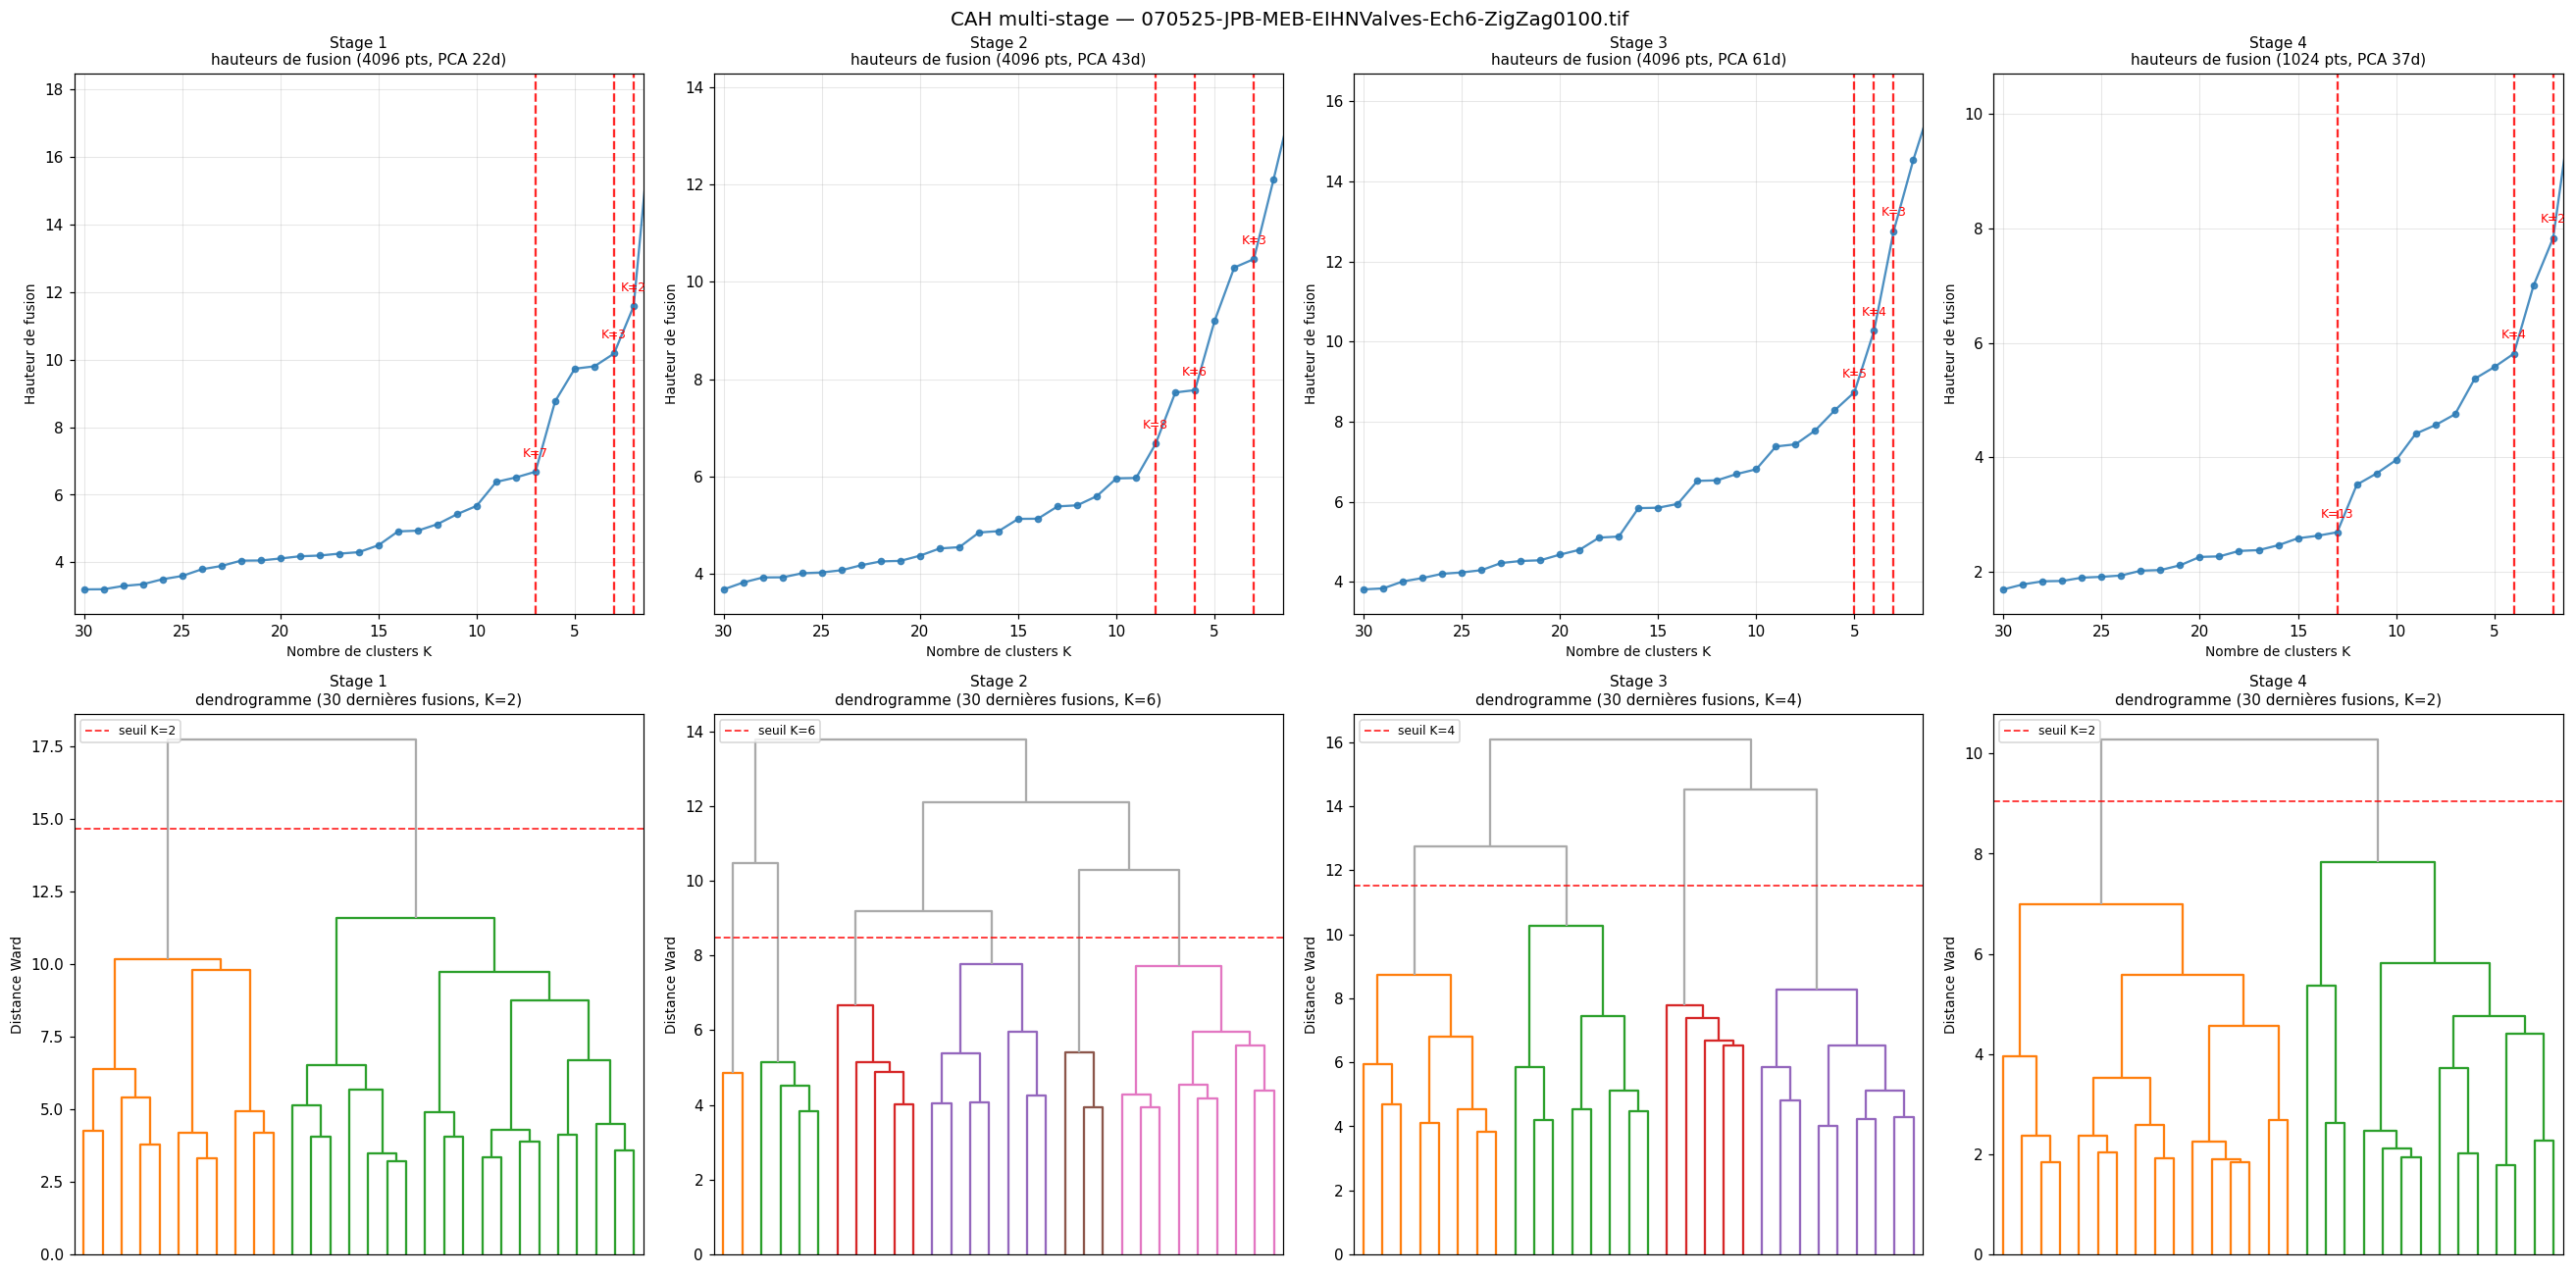

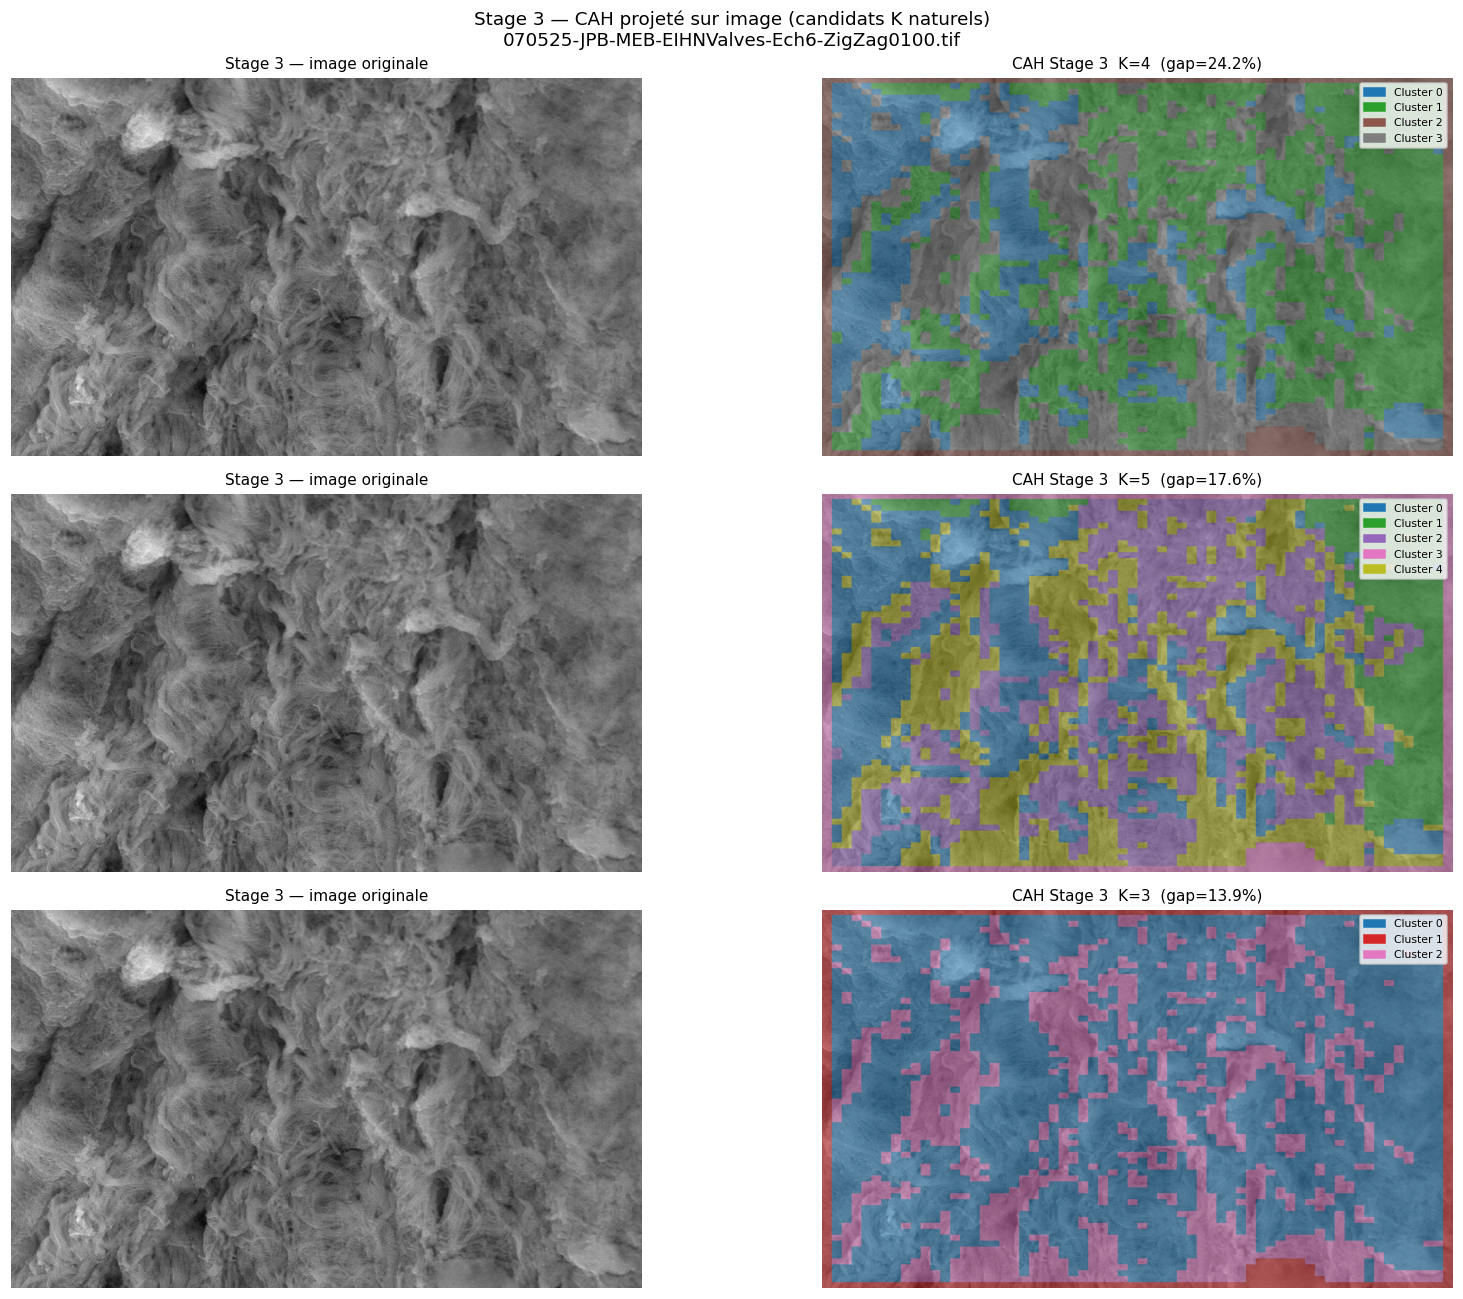

In [7]:
# ── Cell 11 — CAH multi-stage : dendrogramme & hauteurs de fusion ─────────────

import scipy.cluster.hierarchy as sch

# ╔══════════════════════════════════════════════════════════════════╗
# ║  PARAMÈTRE À MODIFIER                                           ║
# ║                                                                  ║
# ║  TARGET_IMG_OVERRIDE = None                                      ║
# ║    → sélection automatique (image avec le + de catégories)      ║
# ║                                                                  ║
# ║  TARGET_IMG_OVERRIDE = 'nom_exact.tif'                          ║
# ║    → forcer une image (annotée ou non)                           ║
# ║                                                                  ║
# ║  Images annotées disponibles (Cell à part) :                    ║
# ║    df = STATE['dataset']                                         ║
# ║    for img, grp in df.groupby('Image_name'):                    ║
# ║        print(img, '→', grp['category'].unique().tolist())       ║
# ╚══════════════════════════════════════════════════════════════════╝

TARGET_IMG_OVERRIDE = None    # ← changer ici  (None = auto)

MAX_POINTS = 4096
TOP_K_GAPS = 3
N_LAST     = 30

# ── 0. Image cible ────────────────────────────────────────────────────────────
def _richest_image():
    best_img, best_cats = None, []
    for img_name, patches in STATE.get('image_index', {}).items():
        cats = sorted(set(p['category'] for p in patches
                          if p['category'] in CATEGORIES_TEST))
        if len(cats) > len(best_cats):
            best_img, best_cats = img_name, cats
    return best_img, best_cats

if TARGET_IMG_OVERRIDE is not None:
    TARGET_IMG = TARGET_IMG_OVERRIDE
    # Vérifier que le fichier existe
    if not (IMG_DIR / TARGET_IMG).exists():
        print(f'⚠️  Fichier introuvable : {IMG_DIR / TARGET_IMG}')
        print('   Vérifie le nom exact (extension .tif, majuscules, tirets).')
        TARGET_IMG = None
    else:
        TARGET_CATS = sorted(set(
            p['category']
            for p in STATE.get('image_index', {}).get(TARGET_IMG, [])
            if p['category'] in CATEGORIES_TEST
        ))
        if not TARGET_CATS:
            print(f'ℹ️  "{TARGET_IMG}" : aucune annotation dans CATEGORIES_TEST.')
            print('   La CAH sera calculée mais pas l\'overlay catégories.')
else:
    TARGET_IMG, TARGET_CATS = _richest_image()

if TARGET_IMG is None:
    print('Aucune image disponible — exécute Cell 2 d\'abord.')
else:
    src = 'override manuel' if TARGET_IMG_OVERRIDE else 'sélection auto (+ de catégories)'
    print(f'Image cible ({src}) :')
    print(f'  {TARGET_IMG}')
    if TARGET_CATS:
        print(f'  Catégories présentes ({len(TARGET_CATS)}) : '
              + ', '.join(f'{c} ({CATEGORIES_NAMES[c]})' for c in TARGET_CATS))
    else:
        print('  Aucune annotation — overlay désactivé')
    print()

    # ── 1. Extraction features (cache STATE) ──────────────────────────────────
    _ck11 = f'_c9_{TARGET_IMG}'
    if _ck11 not in STATE:
        print('Extraction features (forward pass SAM2)...')
        _feats11, _sx11, _sy11 = extract_features(IMG_DIR / TARGET_IMG)
        STATE[_ck11] = {'feats': _feats11, 'sx': _sx11, 'sy': _sy11}
        print('  Mis en cache.')
    else:
        _feats11 = STATE[_ck11]['feats']
        print('Cache utilisé (pas de recalcul).')
    print()

    # ── 2. Pipeline CAH par stage ─────────────────────────────────────────────
    STATE.setdefault('cah', {})
    _rng11 = np.random.default_rng(SEED)

    for _sn in tqdm(STAGE_NAMES, desc='CAH stages'):
        _fm        = _feats11[_sn]
        _H, _W, _C = _fm.shape
        _V_all     = _fm.reshape(-1, _C).astype(np.float32)
        _N_all     = _H * _W

        if _N_all > MAX_POINTS:
            _sidx = np.sort(_rng11.choice(_N_all, size=MAX_POINTS, replace=False))
            _V    = _V_all[_sidx]
            _N    = MAX_POINTS
        else:
            _sidx = np.arange(_N_all)
            _V    = _V_all.copy()
            _N    = _N_all

        _nr = np.linalg.norm(_V, axis=1, keepdims=True)
        _V  = _V / np.where(_nr < 1e-8, 1.0, _nr)

        _n_max   = min(80, _N - 1, _C)
        _pca_obj = PCA(n_components=_n_max, random_state=SEED)
        _V_fit   = _pca_obj.fit_transform(_V)
        _cumvar  = np.cumsum(_pca_obj.explained_variance_ratio_)
        _n_comp  = max(10, min(_n_max, int(np.searchsorted(_cumvar, 0.95)) + 1))
        _V_pca   = _V_fit[:, :_n_comp]
        print(f'  {_sn} : PCA 256→{_n_comp} composantes (95% variance)')

        _Z = sch.linkage(_V_pca, method='ward', metric='euclidean')

        _h_last   = _Z[-N_LAST:, 2]
        _gaps_rel = np.diff(_h_last) / np.where(_h_last[:-1] < 1e-10, 1e-10, _h_last[:-1])
        _top_gi   = np.argsort(_gaps_rel)[-TOP_K_GAPS:][::-1]
        _cands, _seen_k = [], set()
        for _gi in _top_gi:
            _k_c = N_LAST - int(_gi)
            _g_c = float(100 * _gaps_rel[_gi])
            if _k_c >= 2 and _k_c not in _seen_k:
                _cands.append((_k_c, _g_c))
                _seen_k.add(_k_c)

        STATE['cah'][_sn] = {
            'Z': _Z, 'n_points': _N, 'pca_dim': _n_comp,
            'vecteurs': _V, 'pca_model': _pca_obj,
            'idx': _sidx, 'grid_shape': (_H, _W), 'candidates': _cands,
        }

        print(f'{_sn} : {_N} vecteurs → PCA {_n_comp}d → CAH OK')
        print(f'  Candidats K : '
              + (', '.join(f'K={k} (gap={g:.1f}%)' for k, g in _cands) or 'aucun'))
    print()

    # ── 3. Figure principale 2×4 ──────────────────────────────────────────────
    fig, axes = plt.subplots(2, 4, figsize=(24, 12))

    for _ci, _sn in enumerate(STAGE_NAMES):
        _cah    = STATE['cah'][_sn]
        _Z      = _cah['Z']
        _N      = _cah['n_points']
        _dim    = _cah['pca_dim']
        _cands  = _cah['candidates']
        _h_last = _Z[-N_LAST:, 2]

        ax_h = axes[0, _ci]
        _x_k = np.arange(N_LAST, 0, -1)
        ax_h.plot(_x_k, _h_last, 'o-', ms=4, lw=1.5, color='#2c7bb6', alpha=0.85)
        ax_h.set_xlim(N_LAST + 0.5, 1.5)
        for _k_c, _g_c in _cands:
            if 2 <= _k_c <= N_LAST:
                ax_h.axvline(_k_c, color='red', ls='--', lw=1.5, alpha=0.85)
                ax_h.annotate(f'K={_k_c}', xy=(_k_c, _Z[-_k_c, 2]),
                              xytext=(0, 10), textcoords='offset points',
                              fontsize=8, color='red', ha='center')
        ax_h.set_xlabel('Nombre de clusters K', fontsize=9)
        ax_h.set_ylabel('Hauteur de fusion', fontsize=9)
        ax_h.set_title(f'{_sn}\nhauteurs de fusion ({_N} pts, PCA {_dim}d)', fontsize=10)
        ax_h.grid(True, alpha=0.3, lw=0.7)

        ax_d = axes[1, _ci]
        _k_main   = max(2, min((_cands[0][0] if _cands else 3), len(_Z) - 1))
        _c_thresh = (_Z[-_k_main, 2] + _Z[-(_k_main - 1), 2]) / 2
        sch.dendrogram(_Z, ax=ax_d, truncate_mode='lastp', p=N_LAST,
                       color_threshold=_c_thresh, no_labels=True,
                       above_threshold_color='#aaaaaa')
        ax_d.axhline(_c_thresh, color='red', ls='--', lw=1.2, alpha=0.8,
                     label=f'seuil K={_k_main}')
        ax_d.legend(fontsize=8, loc='upper left')
        ax_d.set_title(f'{_sn}\ndendrogramme (30 dernières fusions, K={_k_main})',
                       fontsize=10)
        ax_d.set_ylabel('Distance Ward', fontsize=9)
        ax_d.tick_params(axis='x', labelbottom=False)

    plt.suptitle(f'CAH multi-stage — {TARGET_IMG}', fontsize=13)
    plt.tight_layout()
    plt.show()

    # ── 4. Figure secondaire — Stage 3 projeté sur image ─────────────────────
    _cah3    = STATE['cah']['Stage 3']
    _Z3      = _cah3['Z']
    _cands3  = [(_k, _g) for _k, _g in _cah3['candidates'] if _k >= 2][:3]
    _H3, _W3 = _cah3['grid_shape']
    _idx3    = _cah3['idx']
    _img_arr = np.array(Image.open(IMG_DIR / TARGET_IMG).convert('L'))
    _oh, _ow = _img_arr.shape[:2]
    _nb_k    = len(_cands3)

    if _nb_k == 0:
        print('Aucun candidat K valide pour Stage 3.')
    else:
        fig2, axes2 = plt.subplots(_nb_k, 2, figsize=(16, 4 * _nb_k))
        if _nb_k == 1:
            axes2 = axes2[None, :]

        for _row, (_k_cand, _gap) in enumerate(_cands3):
            _k_cut  = max(2, min(_k_cand, _cah3['n_points'] - 1))
            _labels = sch.fcluster(_Z3, _k_cut, criterion='maxclust') - 1
            _lgrid  = np.full(_H3 * _W3, -1, dtype=int)
            _lgrid[_idx3] = _labels
            _lgrid  = _lgrid.reshape(_H3, _W3)
            _lgrid_up = np.array(
                Image.fromarray((_lgrid + 1).astype(np.uint8)).resize(
                    (_ow, _oh), Image.NEAREST)) - 1

            _tab  = plt.cm.get_cmap('tab10')
            _clrs = np.array([_tab(c / max(_k_cut, 1))[:3] for c in range(_k_cut)])
            _rgb  = np.zeros((*_lgrid_up.shape, 3), dtype=float)
            for _c in range(_k_cut):
                _m = _lgrid_up == _c
                if _m.any():
                    _rgb[_m] = _clrs[_c]

            axes2[_row, 0].imshow(_img_arr, cmap='gray')
            axes2[_row, 0].set_title('Stage 3 — image originale', fontsize=10)
            axes2[_row, 0].axis('off')

            axes2[_row, 1].imshow(_img_arr, cmap='gray')
            axes2[_row, 1].imshow(_rgb, alpha=0.5)
            _hdls = [mpatches.Patch(color=_clrs[_c], label=f'Cluster {_c}')
                     for _c in range(_k_cut)]
            axes2[_row, 1].legend(handles=_hdls, fontsize=7, loc='upper right',
                                  ncol=2 if _k_cut > 5 else 1)
            axes2[_row, 1].set_title(f'CAH Stage 3  K={_k_cut}  (gap={_gap:.1f}%)',
                                     fontsize=10)
            axes2[_row, 1].axis('off')

        plt.suptitle(
            f'Stage 3 — CAH projeté sur image (candidats K naturels)\n{TARGET_IMG}',
            fontsize=12)
        plt.tight_layout()
        plt.show()

In [ ]:
# ── Cell 15 — Calibration τ : distributions cosine intra / inter-catégorie ────

MIN_N15  = 30
MAX_N15  = 500
_rng15   = np.random.default_rng(SEED)

_emb15 = STATE.get('embeddings', {}).get('Stage 3', {})
if not _emb15:
    print('Lance Cell 5 d\'abord.')
else:
    X15 = _emb15['vectors'].astype(np.float32)
    y15 = _emb15['labels'].astype(int)

    # Catégories valides (N >= MIN_N)
    _cats15 = [c for c in CATEGORIES_TEST if int((y15 == c).sum()) >= MIN_N15]
    _skipped = [c for c in CATEGORIES_TEST if c not in _cats15]
    if _skipped:
        print(f'Catégories ignorées (N < {MIN_N15}) : '
              + ', '.join(f'{c} ({CATEGORIES_NAMES[c]})' for c in _skipped))

    # ── Calcul intra-catégorie ─────────────────────────────────────────────────
    _intra15 = {}

    for _c15 in _cats15:
        _Xc15      = X15[y15 == _c15]
        _n_orig15  = len(_Xc15)

        if _n_orig15 > MAX_N15:
            _Xc15 = _Xc15[_rng15.choice(_n_orig15, MAX_N15, replace=False)]
        _n_used15  = len(_Xc15)

        _sim15    = _Xc15 @ _Xc15.T                              # (n_used, n_used)
        _tmask15  = np.triu(np.ones_like(_sim15, dtype=bool), k=1)
        _sims15   = _sim15[_tmask15]                             # triangle sup sans diag

        _intra15[_c15] = {
            'n'     : _n_orig15,
            'n_used': _n_used15,
            'mean'  : float(_sims15.mean()),
            'std'   : float(_sims15.std()),
            'p10'   : float(np.percentile(_sims15, 10)),
            'p25'   : float(np.percentile(_sims15, 25)),
            'p50'   : float(np.percentile(_sims15, 50)),
            'p75'   : float(np.percentile(_sims15, 75)),
            'p90'   : float(np.percentile(_sims15, 90)),
            'sims'  : _sims15,
        }

    # ── Calcul inter-catégorie (paires uniques) ────────────────────────────────
    _inter15 = {}

    for _i15 in range(len(_cats15)):
        for _j15 in range(_i15 + 1, len(_cats15)):
            _ci15, _cj15 = _cats15[_i15], _cats15[_j15]
            _Xi15 = X15[y15 == _ci15]
            _Xj15 = X15[y15 == _cj15]
            if len(_Xi15) > MAX_N15:
                _Xi15 = _Xi15[_rng15.choice(len(_Xi15), MAX_N15, replace=False)]
            if len(_Xj15) > MAX_N15:
                _Xj15 = _Xj15[_rng15.choice(len(_Xj15), MAX_N15, replace=False)]
            _sij15 = (_Xi15 @ _Xj15.T).flatten()
            _inter15[(_ci15, _cj15)] = {
                'mean': float(_sij15.mean()),
                'std' : float(_sij15.std()),
            }

    # ── Tau ───────────────────────────────────────────────────────────────────
    _means15     = [_intra15[c]['mean'] for c in _cats15]
    _tau_cons15  = float(min(_means15))
    _tau_mod15   = float(np.mean(_means15))
    _tau_agg15   = float(max(_means15))

    STATE['tau'] = {
        'conservateur': _tau_cons15,
        'modere'      : _tau_mod15,
        'agressif'    : _tau_agg15,
        'intra_stats' : _intra15,
        'inter_stats' : _inter15,
    }

    # ── Tableau console ────────────────────────────────────────────────────────
    print('╔══════════════════╦══════╦════════╦════════╦══════╦══════╦══════╗')
    print('║ Catégorie        ║  N   ║  mean  ║  std   ║  p25 ║  p50 ║  p75 ║')
    print('╠══════════════════╬══════╬════════╬════════╬══════╬══════╬══════╣')
    for _c15 in _cats15:
        _s15 = _intra15[_c15]
        _nm15 = CATEGORIES_NAMES[_c15][:16]
        print(f'║ {_nm15:<16} ║ {_s15["n"]:>4} ║  {_s15["mean"]:.3f} ║  {_s15["std"]:.3f} ║'
              f' {_s15["p25"]:.2f} ║ {_s15["p50"]:.2f} ║ {_s15["p75"]:.2f} ║')
    print('╚══════════════════╩══════╩════════╩════════╩══════╩══════╩══════╝')
    print()
    print(f'τ conservateur (min des means) = {_tau_cons15:.4f}')
    print(f'τ modéré       (mean des means) = {_tau_mod15:.4f}')
    print(f'τ agressif     (max des means)  = {_tau_agg15:.4f}')
    print(f'→ Recommandation : utiliser τ = {_tau_cons15:.4f} (conservateur)')
    print(f'  Deux clusters seront fusionnés ssi sim(centroïde_i, centroïde_j) > τ')

    # ── Figure 1 — Distributions intra-catégorie ─────────────────────────────
    _nc_fig15 = len(_cats15)
    fig15a, _axes15a = plt.subplots(1, _nc_fig15, figsize=(14, 5))
    if _nc_fig15 == 1:
        _axes15a = [_axes15a]

    for _ax15, _c15 in zip(_axes15a, _cats15):
        _s15  = _intra15[_c15]
        _col15 = CATEGORIES[_c15]['color']

        _ax15.hist(_s15['sims'], bins=40, color=_col15, alpha=0.75, density=True)
        _ax15.axvline(_s15['mean'], color='red',    ls='--', lw=1.5, label='mean')
        _ax15.axvline(_s15['p25'],  color='orange', ls='--', lw=1.2, label='p25')
        _ax15.axvline(_s15['p75'],  color='green',  ls='--', lw=1.2, label='p75')
        _ax15.set_xlim(0, 1)
        _ax15.set_xlabel('Similarité cosine', fontsize=9)
        _ax15.set_title(
            f"Cat {_c15} — {CATEGORIES_NAMES[_c15]}\n"
            f"(n={_s15['n']}, {_s15['n_used']*(_s15['n_used']-1)//2:,} paires)",
            fontsize=9)
        _ax15.annotate(
            f"μ={_s15['mean']:.2f}  σ={_s15['std']:.2f}\n"
            f"p25={_s15['p25']:.2f}  p75={_s15['p75']:.2f}",
            xy=(0.03, 0.97), xycoords='axes fraction', va='top', fontsize=8,
            bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.7))
        if _ax15 is _axes15a[0]:
            _ax15.legend(fontsize=7, loc='upper right')

    fig15a.suptitle('Distributions cosine intra-catégorie (Stage 3)', fontsize=11)
    plt.tight_layout()

    # ── Figure 2 — Boxplots + Heatmap ─────────────────────────────────────────
    fig15b, (ax15_box, ax15_heat) = plt.subplots(1, 2, figsize=(12, 6))

    # Boxplots intra
    _bp_data15   = [_intra15[c]['sims'] for c in _cats15]
    _bp_cols15   = [CATEGORIES[c]['color'] for c in _cats15]
    _bp15 = ax15_box.boxplot(_bp_data15, patch_artist=True,
                              medianprops=dict(color='black', lw=2))
    for _patch15, _col15 in zip(_bp15['boxes'], _bp_cols15):
        _patch15.set_facecolor(_col15)
        _patch15.set_alpha(0.75)

    # Baseline empirique : similarité cosine entre paires aléatoires
    _rng_base15 = np.random.default_rng(SEED)
    _idx_a15 = _rng_base15.choice(len(X15), 2000, replace=True)
    _idx_b15 = _rng_base15.choice(len(X15), 2000, replace=True)
    _baseline_emp15 = float((X15[_idx_a15] * X15[_idx_b15]).sum(axis=1).mean())
    ax15_box.axhline(_baseline_emp15, color='gray', ls=':', lw=1.2, alpha=0.8,
                     label=f'Baseline aléatoire empirique = {_baseline_emp15:.3f}')
    ax15_box.annotate(f'baseline = {_baseline_emp15:.3f}',
                      xy=(0.5, _baseline_emp15), xycoords=('axes fraction', 'data'),
                      xytext=(0, 5), textcoords='offset points',
                      fontsize=8, color='gray', ha='center')
    ax15_box.set_xticks(range(1, _nc_fig15 + 1))
    ax15_box.set_xticklabels([CATEGORIES_NAMES[c][:10] for c in _cats15],
                               fontsize=8, rotation=15)
    ax15_box.set_ylabel('Similarité cosine intra', fontsize=9)
    ax15_box.set_title('Distribution intra-catégorie — calibration τ', fontsize=10)
    ax15_box.set_ylim(0, 1)
    ax15_box.grid(True, alpha=0.3, axis='y')

    # Heatmap intra/inter
    _ncat15 = len(_cats15)
    _mat15  = np.zeros((_ncat15, _ncat15))
    for _i15, _ci15 in enumerate(_cats15):
        for _j15, _cj15 in enumerate(_cats15):
            if _ci15 == _cj15:
                _mat15[_i15, _j15] = _intra15[_ci15]['mean']
            else:
                _key15 = (_ci15, _cj15) if (_ci15, _cj15) in _inter15 else (_cj15, _ci15)
                _mat15[_i15, _j15] = _inter15[_key15]['mean']

    _im15 = ax15_heat.imshow(_mat15, cmap='RdYlGn', vmin=0.3, vmax=1.0)
    plt.colorbar(_im15, ax=ax15_heat, fraction=0.046, pad=0.04)
    _lbls15 = [CATEGORIES_NAMES[c][:8] for c in _cats15]
    ax15_heat.set_xticks(range(_ncat15))
    ax15_heat.set_yticks(range(_ncat15))
    ax15_heat.set_xticklabels(_lbls15, fontsize=8, rotation=30, ha='right')
    ax15_heat.set_yticklabels(_lbls15, fontsize=8)
    for _i15 in range(_ncat15):
        for _j15 in range(_ncat15):
            _v15 = _mat15[_i15, _j15]
            ax15_heat.text(_j15, _i15, f'{_v15:.2f}', ha='center', va='center',
                            fontsize=9, color='white' if _v15 < 0.55 else 'black',
                            fontweight='bold' if _i15 == _j15 else 'normal')
    ax15_heat.set_title('Similarité cosine : intra (diag) vs inter (hors-diag)',
                         fontsize=10)

    fig15b.suptitle('Calibration τ — Stage 3', fontsize=11)
    plt.tight_layout()

    plt.show()

In [ ]:
# ── Cell 16 — CAH Stage 3 sur toutes les images MEB ──────────────────────────
import scipy.cluster.hierarchy as sch   # au cas où Cell 11 n'a pas été exécutée

MAX_POINTS16 = 4096
N_LAST16     = 30
PCA_VAR16    = 0.95
PCA_MIN16    = 10
PCA_MAX16    = 80

_all_imgs16 = sorted([f for f in IMG_DIR.iterdir() if f.suffix in ('.tif', '.tiff')])
print(f'{len(_all_imgs16)} images trouvées dans {IMG_DIR.name}')

STATE.setdefault('cah_all', {})
_errors16 = []

for _ipath16 in tqdm(_all_imgs16, desc='CAH Stage 3 — toutes images'):
    _iname16 = _ipath16.name

    # Skip si déjà calculé
    if _iname16 in STATE['cah_all'] and 'Z' in STATE['cah_all'][_iname16]:
        continue

    try:
        # 1. Features depuis cache ou extraction
        _ck16 = f'_c9_{_iname16}'
        if _ck16 in STATE:
            _fm16 = STATE[_ck16]['feats']['Stage 3']
        else:
            _feats16, _sx16, _sy16 = extract_features(_ipath16)
            STATE[_ck16] = {'feats': _feats16, 'sx': _sx16, 'sy': _sy16}
            _fm16 = _feats16['Stage 3']

        # 2. Flatten + L2-norm (Stage 3 = 64×64 = 4096 <= MAX_POINTS → pas de sous-éch.)
        _V16 = _fm16.reshape(-1, 256).astype(np.float32)
        _V16 = _V16 / np.linalg.norm(_V16, axis=1, keepdims=True).clip(min=1e-8)

        # 3. PCA → PCA_VAR% variance
        _pca16  = PCA(n_components=PCA_MAX16, random_state=SEED)
        _Vfit16 = _pca16.fit_transform(_V16)
        _cv16   = np.cumsum(_pca16.explained_variance_ratio_)
        _n16    = int(np.clip(int(np.searchsorted(_cv16, PCA_VAR16)) + 1,
                              PCA_MIN16, PCA_MAX16))
        _Vpca16 = _Vfit16[:, :_n16]

        # 4. CAH Ward
        _Z16 = sch.linkage(_Vpca16, method='ward', metric='euclidean')

        # 5. K_auto = gap maximum parmi les N_LAST dernières fusions
        _h16    = _Z16[-N_LAST16:, 2]
        _gaps16 = np.diff(_h16) / np.where(_h16[:-1] < 1e-10, 1e-10, _h16[:-1])
        _gi16   = int(np.argmax(_gaps16))
        _K_auto16 = N_LAST16 - _gi16

        _top3_gi16 = np.argsort(_gaps16)[-3:][::-1]
        _cands16 = [(N_LAST16 - int(gi), float(100 * _gaps16[gi]))
                    for gi in _top3_gi16 if N_LAST16 - int(gi) >= 2]

        STATE['cah_all'][_iname16] = {
            'K_auto'    : int(_K_auto16),
            'gap_auto'  : float(100 * _gaps16[_gi16]),
            'candidates': _cands16,
            'pca_dim'   : int(_n16),
            'Z'         : _Z16,
        }

    except Exception as _e16:
        print(f'  ⚠️  {_iname16[-30:]} : {_e16}')
        _errors16.append(_iname16)

if _errors16:
    print(f'\n{len(_errors16)} erreurs : {[n[-20:] for n in _errors16]}')

# ── Arrays résultats ──────────────────────────────────────────────────────────
_res16     = STATE['cah_all']
_names16   = sorted(_res16.keys())
_K_arr16   = np.array([_res16[n]['K_auto']   for n in _names16])
_gap_arr16 = np.array([_res16[n]['gap_auto']  for n in _names16])
_pca_arr16 = np.array([_res16[n]['pca_dim']   for n in _names16])
_N16       = len(_names16)

# ── Print console ─────────────────────────────────────────────────────────────
print(f'\n════ CAH Stage 3 — Résultats sur {_N16} images ════')
print()
print('Distribution K_auto :')
print(f'  min={_K_arr16.min()}  max={_K_arr16.max()}'
      f'  mean={_K_arr16.mean():.1f}  median={int(np.median(_K_arr16))}'
      f'  std={_K_arr16.std():.1f}')
print()

for _label16, _order16 in [('K le plus élevé', np.argsort(_K_arr16)[-10:][::-1]),
                             ('K le plus faible', np.argsort(_K_arr16)[:10])]:
    print(f'Top-10 images {_label16} :')
    print('╔══════════════════════════════╦══════╦══════════╦═════════╗')
    print('║ Image                        ║ K    ║ gap (%)  ║ PCA dim ║')
    print('╠══════════════════════════════╬══════╬══════════╬═════════╣')
    for _ii16 in _order16:
        _nm16 = _names16[_ii16][-28:]
        print(f'║ {_nm16:<28} ║ {_K_arr16[_ii16]:>4} ║ {_gap_arr16[_ii16]:>7.1f}% ║  {_pca_arr16[_ii16]:>5}  ║')
    print('╚══════════════════════════════╩══════╩══════════╩═════════╝')
    print()

print('K_auto par valeur :')
_k_uniq16    = sorted(np.unique(_K_arr16))
_k_max_cnt16 = max(int((_K_arr16 == k).sum()) for k in _k_uniq16)
for _k16 in _k_uniq16:
    _cnt16 = int((_K_arr16 == _k16).sum())
    _bar16 = '█' * max(1, int(_cnt16 * 40 / _k_max_cnt16))
    print(f'  K={_k16:<3} → {_cnt16:>3} images  {_bar16}')

# ── Figure 1 — Distribution K_auto ───────────────────────────────────────────
fig16a, axes16a = plt.subplots(1, 3, figsize=(16, 5))
_cmap16    = plt.cm.get_cmap('viridis')
_k_min16   = int(_K_arr16.min())
_k_max16   = int(_K_arr16.max())
_k_range16 = max(_k_max16 - _k_min16, 1)

_bins16 = [k - 0.5 for k in range(_k_min16, _k_max16 + 2)]
_cnts16, _edges16, _patches16 = axes16a[0].hist(
    _K_arr16, bins=_bins16, edgecolor='white', linewidth=0.5)
for _i16, _patch16 in enumerate(_patches16):
    _k16 = _k_min16 + _i16
    _patch16.set_facecolor(_cmap16((_k16 - _k_min16) / _k_range16))
    _c16 = int(_cnts16[_i16])
    if _c16 > 0:
        _cx16 = (_edges16[_i16] + _edges16[_i16 + 1]) / 2
        axes16a[0].text(_cx16, _c16 + 0.15, str(_c16),
                        ha='center', va='bottom', fontsize=8)

_med16 = float(np.median(_K_arr16))
_mn16  = float(_K_arr16.mean())
axes16a[0].axvline(_med16, color='red',    ls='--', lw=1.5, label=f'médiane={_med16:.0f}')
axes16a[0].axvline(_mn16,  color='orange', ls='--', lw=1.5, label=f'moyenne={_mn16:.1f}')
axes16a[0].annotate(f'médiane={_med16:.0f}  moyenne={_mn16:.1f}',
                    xy=(0.97, 0.97), xycoords='axes fraction', ha='right', va='top',
                    fontsize=8, bbox=dict(boxstyle='round', fc='white', alpha=0.8))
axes16a[0].legend(fontsize=8, loc='upper left')
axes16a[0].set_xlabel('K naturel détecté', fontsize=10)
axes16a[0].set_ylabel("Nombre d'images", fontsize=10)
axes16a[0].set_title(f'Distribution K_auto — {_N16} images MEB', fontsize=11)

_sc16 = axes16a[1].scatter(_K_arr16, _gap_arr16, c=_K_arr16, cmap='viridis',
                             s=60, alpha=0.75, edgecolors='grey', linewidths=0.4)
plt.colorbar(_sc16, ax=axes16a[1], label='K_auto', fraction=0.046, pad=0.04)
for _ii16 in np.argsort(_gap_arr16)[-3:][::-1]:
    axes16a[1].annotate(
        _names16[_ii16][-15:],
        xy=(_K_arr16[_ii16], _gap_arr16[_ii16]),
        xytext=(5, 4), textcoords='offset points', fontsize=7, color='red')
axes16a[1].set_xlabel('K naturel', fontsize=10)
axes16a[1].set_ylabel('Gap au K naturel (%)', fontsize=10)
axes16a[1].set_title('K naturel vs confiance du gap', fontsize=11)
axes16a[1].grid(True, alpha=0.3)

_groups16 = {}
for _n16, _k16 in zip(_names16, _K_arr16):
    _g16 = _n16.split('-')[0]
    _groups16.setdefault(_g16, []).append(int(_k16))
_g_names16 = sorted(_groups16.keys())
_g_data16  = [_groups16[g] for g in _g_names16]
_bp16 = axes16a[2].boxplot(_g_data16, patch_artist=True,
                            medianprops=dict(color='black', lw=2))
for _p16, _col16 in zip(_bp16['boxes'],
                         [_cmap16(i / max(len(_g_names16)-1, 1))
                          for i in range(len(_g_names16))]):
    _p16.set_facecolor(_col16); _p16.set_alpha(0.75)
axes16a[2].set_xticks(range(1, len(_g_names16) + 1))
axes16a[2].set_xticklabels(_g_names16, fontsize=8, rotation=45, ha='right')
axes16a[2].set_ylabel('K_auto', fontsize=10)
axes16a[2].set_title("K_auto par type d'image", fontsize=11)
axes16a[2].grid(True, alpha=0.3, axis='y')

fig16a.suptitle('CAH Stage 3 — Distribution K_auto sur toutes les images', fontsize=12)
plt.tight_layout()

# ── Figure 2 — Mosaïque 9 images représentatives ─────────────────────────────
_sorted_k16 = sorted(_names16, key=lambda n: _res16[n]['K_auto'])
_Nimg16     = len(_sorted_k16)
_mid16      = _Nimg16 // 2

_cands_sel16 = (
    _sorted_k16[:3] +
    _sorted_k16[max(0, _mid16 - 1):min(_Nimg16, _mid16 + 2)] +
    _sorted_k16[-3:]
)
_sel9_16 = []
_seen16  = set()
for _n16 in _cands_sel16:
    if _n16 not in _seen16:
        _sel9_16.append(_n16)
        _seen16.add(_n16)
_sel9_16 = _sel9_16[:9]

fig16b, _axes16b = plt.subplots(3, 3, figsize=(18, 12))
_axes16b = _axes16b.flatten()

for _p16, _iname16 in enumerate(_sel9_16):
    _ax16  = _axes16b[_p16]
    _r16   = _res16[_iname16]
    _K16   = _r16['K_auto']
    _g16   = _r16['gap_auto']
    _Z16   = _r16['Z']

    _iarr16 = np.array(Image.open(IMG_DIR / _iname16).convert('L'))
    _oh16, _ow16 = _iarr16.shape[:2]

    _lbl16   = sch.fcluster(_Z16, _K16, criterion='maxclust') - 1
    _lgrid16 = _lbl16.reshape(64, 64)
    _lup16   = np.array(
        Image.fromarray((_lgrid16 + 1).astype(np.uint8)).resize((_ow16, _oh16), Image.NEAREST)
    ) - 1

    _tab16  = plt.cm.get_cmap('tab10')
    _clrs16 = np.array([_tab16(c / max(_K16, 1))[:3] for c in range(_K16)])
    _rgb16  = np.zeros((*_lup16.shape, 3), dtype=float)
    for _c16 in range(_K16):
        _m16 = _lup16 == _c16
        if _m16.any():
            _rgb16[_m16] = _clrs16[_c16]

    _ax16.imshow(_iarr16, cmap='gray')
    _ax16.imshow(_rgb16, alpha=0.5)
    _ax16.set_title(f'{_iname16[-28:]}\nK={_K16}  gap={_g16:.1f}%', fontsize=8)
    _ax16.axis('off')

for _p16 in range(len(_sel9_16), 9):
    _axes16b[_p16].axis('off')

fig16b.suptitle('Exemples CAH K_auto variable — Stage 3', fontsize=13)
plt.tight_layout()

plt.show()

print(f"\nSTATE['cah_all'] complet : {len(STATE['cah_all'])} images.")

In [ ]:
# ── Cell 17 — τ intra-image : similarité cosine par (image, catégorie) ───────

_emb17 = STATE.get('embeddings', {}).get('Stage 3', {})
if not _emb17:
    print('Lance Cell 5 d\'abord.')
else:
    _X17      = _emb17['vectors'].astype(np.float32)
    _y17      = _emb17['labels'].astype(int)
    _ids17    = _emb17['img_ids']
    _rng17    = np.random.default_rng(SEED)

    _imgs17    = sorted(STATE['image_index'].keys())
    _results17 = {}

    # ── Calcul intra-image par (image, catégorie) ─────────────────────────────
    for _img17 in _imgs17:
        for _cat17 in CATEGORIES_TEST:
            _mask17 = (_ids17 == _img17) & (_y17 == _cat17)
            _n17    = int(_mask17.sum())
            if _n17 < 2:
                continue
            _V17      = _X17[_mask17]
            _sim17    = _V17 @ _V17.T
            _triu17   = np.triu(np.ones(_sim17.shape, dtype=bool), k=1)
            _paires17 = _sim17[_triu17]
            _results17[(_img17, _cat17)] = {
                'mean'      : float(_paires17.mean()),
                'std'       : float(_paires17.std()),
                'n_patches' : _n17,
                'n_paires'  : len(_paires17),
                'paires'    : _paires17,
            }

    # ── Agrégation par catégorie ──────────────────────────────────────────────
    _tau_intra17 = {}
    for _cat17 in CATEGORIES_TEST:
        _means17 = [_results17[(_img17, _cat17)]['mean']
                    for _img17 in _imgs17 if (_img17, _cat17) in _results17]
        if not _means17:
            continue
        _tau_intra17[_cat17] = {
            'means' : _means17,
            'tau'   : float(np.mean(_means17)),
            'std'   : float(np.std(_means17)),
            'n_imgs': len(_means17),
        }

    STATE['tau_intra'] = _tau_intra17

    # τ global par catégorie depuis Cell 15 (valeur par cat, pas un scalaire unique)
    _intra_stats17 = STATE.get('tau', {}).get('intra_stats', {})
    _tau_glob17 = {c: _intra_stats17[c]['mean']
                   for c in CATEGORIES_TEST if c in _intra_stats17}

    _cats_valid17  = [c for c in CATEGORIES_TEST if c in _tau_intra17]
    _tau_corrige17 = float(min(_tau_intra17[c]['tau'] for c in _cats_valid17)) \
                     if _cats_valid17 else None

    # ── Print console ─────────────────────────────────────────────────────────
    _n_pairs_imgs17 = len(set(img for (img, _) in _results17))
    print(f'Images annotées avec au moins une paire : {_n_pairs_imgs17}')
    print()
    print('╔══════════════════╦════════╦═══════════╦═══════════╦══════════╗')
    print('║ Catégorie        ║ N imgs ║ τ intra   ║ std inter ║ τ global ║')
    print('║                  ║        ║ (intra-im)║  -images  ║ (Cell 15)║')
    print('╠══════════════════╬════════╬═══════════╬═══════════╬══════════╣')
    for _cat17 in CATEGORIES_TEST:
        if _cat17 not in _tau_intra17:
            continue
        _ti17  = _tau_intra17[_cat17]
        _tg_v17 = _tau_glob17.get(_cat17, None)
        _tg_s17 = f'{_tg_v17:.3f}' if _tg_v17 is not None else '  N/A '
        _nm17  = CATEGORIES_NAMES[_cat17][:16]
        print(f'║ {_nm17:<16} ║ {_ti17["n_imgs"]:>6} ║   {_ti17["tau"]:.3f}   ║'
              f'   {_ti17["std"]:.3f}   ║  {_tg_s17}  ║')
    print('╚══════════════════╩════════╩═══════════╩═══════════╩══════════╝')
    if _tau_corrige17:
        print(f'→ τ corrigé recommandé : min(τ_intra) = {_tau_corrige17:.4f}')

    # ── Figure 1 — Boxplot + stripplot ────────────────────────────────────────
    fig17a, ax17a = plt.subplots(figsize=(12, 6))

    _x_pos17 = {c: i for i, c in enumerate(_cats_valid17)}
    for _cat17 in _cats_valid17:
        _ti17  = _tau_intra17[_cat17]
        _xi17  = _x_pos17[_cat17]
        _col17 = CATEGORIES[_cat17]['color']

        ax17a.boxplot(_ti17['means'], positions=[_xi17], widths=0.4,
                      patch_artist=True, manage_ticks=False,
                      medianprops=dict(color='black', lw=2),
                      boxprops=dict(facecolor=_col17, alpha=0.5),
                      whiskerprops=dict(color='grey'),
                      capprops=dict(color='grey'),
                      flierprops=dict(marker='o', markersize=4,
                                      markerfacecolor=_col17, alpha=0.4))

        _jitter17 = _rng17.uniform(-0.12, 0.12, len(_ti17['means']))
        ax17a.scatter(_xi17 + _jitter17, _ti17['means'],
                      color=_col17, s=40, alpha=0.85, zorder=5,
                      edgecolors='white', linewidths=0.5)

        # Tick τ global par catégorie (segment horizontal centré sur chaque boxplot)
        _tg_v17 = _tau_glob17.get(_cat17, None)
        if _tg_v17 is not None:
            ax17a.hlines(_tg_v17, _xi17 - 0.28, _xi17 + 0.28,
                         color='red', lw=2.0, ls='--', zorder=6)

    # Ligne verte τ intra-image corrigé (mean global)
    if _tau_corrige17:
        _mean_tau_intra17 = float(np.mean([_tau_intra17[c]['tau'] for c in _cats_valid17]))
        ax17a.axhline(_mean_tau_intra17, color='green', ls='--', lw=1.5,
                      label=f'τ intra-image corrigé (mean) = {_mean_tau_intra17:.3f}')

    # Entrées légende manuelles
    from matplotlib.lines import Line2D
    _leg17 = [Line2D([0], [0], color='red',   ls='--', lw=2,
                     label='τ global Cell 15 (par catégorie)'),
              Line2D([0], [0], color='green', ls='--', lw=1.5,
                     label=f'τ intra-image corrigé (mean) = {_mean_tau_intra17:.3f}'
                           if _tau_corrige17 else 'τ intra-image')]
    ax17a.legend(handles=_leg17, fontsize=9)

    ax17a.set_xticks(range(len(_cats_valid17)))
    ax17a.set_xticklabels([CATEGORIES_NAMES[c] for c in _cats_valid17], fontsize=9)
    ax17a.set_ylim(0, 1)
    ax17a.set_xlabel('Catégorie', fontsize=10)
    ax17a.set_ylabel('Mean cosine sim intra-image', fontsize=10)
    ax17a.set_title('Stabilité de τ par image — patches même catégorie même image',
                    fontsize=11)
    ax17a.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()

    # ── Figure 2 — Heatmap images × catégories ────────────────────────────────
    _img_list17 = sorted(set(img for (img, _) in _results17))
    _Nrow17     = len(_img_list17)
    _Ncol17     = len(_cats_valid17)

    _mat17 = np.full((_Nrow17, _Ncol17), np.nan)
    for _ri17, _img17 in enumerate(_img_list17):
        for _ci17, _cat17 in enumerate(_cats_valid17):
            if (_img17, _cat17) in _results17:
                _mat17[_ri17, _ci17] = _results17[(_img17, _cat17)]['mean']

    _cmap17 = plt.cm.get_cmap('RdYlGn').copy()
    _cmap17.set_bad('#eeeeee')
    _mat17_ma = np.ma.masked_invalid(_mat17)

    fig17b, ax17b = plt.subplots(figsize=(14, max(6, _Nrow17 * 0.35 + 1)))
    _im17 = ax17b.imshow(_mat17_ma, cmap=_cmap17, vmin=0.3, vmax=1.0,
                          aspect='auto', interpolation='nearest')
    plt.colorbar(_im17, ax=ax17b, label='Mean cosine intra-image', fraction=0.04, pad=0.02)
    ax17b.set_xticks(range(_Ncol17))
    ax17b.set_xticklabels([CATEGORIES_NAMES[c][:12] for c in _cats_valid17], fontsize=9)
    ax17b.set_yticks(range(_Nrow17))
    ax17b.set_yticklabels([n[-20:] for n in _img_list17], fontsize=7)
    ax17b.set_title('Similarité intra-image par catégorie — images annotées', fontsize=11)
    for _ri17 in range(_Nrow17):
        for _ci17 in range(_Ncol17):
            _v17 = _mat17[_ri17, _ci17]
            if not np.isnan(_v17):
                ax17b.text(_ci17, _ri17, f'{_v17:.1f}', ha='center', va='center',
                            fontsize=7, color='white' if _v17 < 0.5 else 'black')
    plt.tight_layout()

    # ── Figure 3 — τ intra vs τ global par catégorie (barplot groupé) ─────────
    fig17c, ax17c = plt.subplots(figsize=(10, 5))

    _width17 = 0.35
    _xs17    = np.arange(len(_cats_valid17))
    _tau_i17 = np.array([_tau_intra17[c]['tau'] for c in _cats_valid17])
    _std_i17 = np.array([_tau_intra17[c]['std'] for c in _cats_valid17])
    # τ global PAR CATÉGORIE (valeur correcte, non biaisée par un scalaire unique)
    _tau_g17 = np.array([_tau_glob17.get(c, np.nan) for c in _cats_valid17])

    _bars_i17 = ax17c.bar(_xs17 - _width17/2, _tau_i17, _width17,
                           yerr=_std_i17, capsize=5,
                           color=[CATEGORIES[c]['color'] for c in _cats_valid17],
                           alpha=0.85, label='τ intra-image',
                           error_kw=dict(ecolor='#333333', lw=1.5))
    _bars_g17 = ax17c.bar(_xs17 + _width17/2, np.nan_to_num(_tau_g17), _width17,
                           color='#aaaaaa', alpha=0.7,
                           label='τ global par catégorie (Cell 15)')

    # Baseline empirique pour Cell 17
    _rng_base17 = np.random.default_rng(SEED)
    _idx_a17 = _rng_base17.choice(len(_X17), 2000, replace=True)
    _idx_b17 = _rng_base17.choice(len(_X17), 2000, replace=True)
    _baseline_emp17 = float((_X17[_idx_a17] * _X17[_idx_b17]).sum(axis=1).mean())
    ax17c.axhline(_baseline_emp17, color='gray', ls=':', lw=1.2, alpha=0.8,
                  label=f'Baseline aléatoire empirique = {_baseline_emp17:.3f}')
    ax17c.set_xticks(_xs17)
    ax17c.set_xticklabels([CATEGORIES_NAMES[c] for c in _cats_valid17], fontsize=9)
    ax17c.set_ylabel('Valeur τ', fontsize=10)
    ax17c.set_ylim(0, 1.05)
    ax17c.set_title('τ intra-image vs τ global par catégorie', fontsize=11)
    ax17c.legend(fontsize=9)
    ax17c.grid(True, alpha=0.3, axis='y')

    for _bar17, _v17, _s17 in zip(_bars_i17, _tau_i17, _std_i17):
        ax17c.text(_bar17.get_x() + _bar17.get_width()/2,
                   _v17 + _s17 + 0.02, f'{_v17:.3f}',
                   ha='center', va='bottom', fontsize=8)
    for _bar17, _v17 in zip(_bars_g17, _tau_g17):
        if not np.isnan(_v17):
            ax17c.text(_bar17.get_x() + _bar17.get_width()/2,
                       _v17 + 0.02, f'{_v17:.3f}',
                       ha='center', va='bottom', fontsize=8, color='#555555')

    plt.tight_layout()
    plt.show()

In [8]:
# ── Cell 18 — Diffusion Maps sur features Stage 3 ────────────────────────────
# Coifman & Lafon (2006), Applied and Computational Harmonic Analysis
# Mapping continu révélant les transitions texturales d'une image MEB.

from sklearn.neighbors import NearestNeighbors
from scipy.sparse import csr_matrix, diags as _sp_diags
from scipy.sparse.linalg import eigs as _sp_eigs

_dm_cah3     = STATE.get('cah', {}).get('Stage 3', {})
if not _dm_cah3 or 'vecteurs' not in _dm_cah3:
    print("Lance Cell 11 d'abord (STATE['cah']['Stage 3'] requis).")
else:
    _dm_V        = _dm_cah3['vecteurs'].astype(np.float32)  # (4096, 256) L2-norm
    _dm_H, _dm_W = _dm_cah3['grid_shape']                   # 64, 64
    _dm_N        = len(_dm_V)                               # 4096
    _dm_tgt      = STATE['cah'].get('target_img', None)
    if _dm_tgt is None:
        print("TARGET_IMG non trouvé dans STATE['cah']['target_img'].")
    else:

        _dm_K_NN = 30

        # ── Étape 1 — Matrice de similarité sparse (k-NN) ─────────────────────
        print('k-NN graph...')
        _dm_nbrs  = NearestNeighbors(n_neighbors=_dm_K_NN + 1,
                                      algorithm='ball_tree').fit(_dm_V)
        _dm_dists, _dm_idx = _dm_nbrs.kneighbors(_dm_V)   # (N, K+1)

        # ε automatique = médiane des distances au K-ème voisin au carré
        _dm_eps  = float(np.median(_dm_dists[:, _dm_K_NN])**2)

        # Construction sparse vectorisée (évite boucle Python)
        _dm_rows = np.repeat(np.arange(_dm_N), _dm_K_NN)
        _dm_cols = _dm_idx[:, 1:].flatten()
        _dm_vals = np.exp(-_dm_dists[:, 1:]**2 / _dm_eps).flatten().astype(np.float32)

        # Symétrie : empiler (i→j) et (j→i) puis sommer (csr gère ça)
        _dm_W = csr_matrix(
            (np.concatenate([_dm_vals, _dm_vals]),
             (np.concatenate([_dm_rows, _dm_cols]),
              np.concatenate([_dm_cols, _dm_rows]))),
            shape=(_dm_N, _dm_N))
        _dm_W.data = np.clip(_dm_W.data, 0, 1)

        # ── Étape 2 — Normalisation → matrice de Markov ───────────────────────
        _dm_D_vec = np.array(_dm_W.sum(axis=1)).flatten()
        _dm_D_inv = _sp_diags(1.0 / np.where(_dm_D_vec < 1e-10, 1.0, _dm_D_vec))
        _dm_P     = _dm_D_inv @ _dm_W   # stochastique sparse

        # ── Étape 3 — Vecteurs propres via eigs (sparse) ──────────────────────
        print('Vecteurs propres (eigs)...')
        _dm_v0   = np.random.default_rng(SEED).random(_dm_N).astype(np.float64)
        _dm_evals, _dm_evecs = _sp_eigs(_dm_P, k=4, which='LR', v0=_dm_v0)

        # Trier par valeur propre décroissante, prendre partie réelle
        _dm_s    = np.argsort(-_dm_evals.real)
        _dm_evals = _dm_evals[_dm_s].real
        _dm_evecs = _dm_evecs[:, _dm_s].real

        _dm_phi1 = _dm_evecs[:, 1]   # 2ème vecteur propre (φ₁)
        _dm_phi2 = _dm_evecs[:, 2]   # 3ème vecteur propre (φ₂)

        # ── Étape 4 — Mise en grille 64×64 ────────────────────────────────────
        _dm_phi1_grid = _dm_phi1.reshape(_dm_H, _dm_W)
        _dm_phi2_grid = _dm_phi2.reshape(_dm_H, _dm_W)

        # ── Étape 5 — Carte de gradient (frontières texturales) ───────────────
        _dm_grad_y = np.diff(_dm_phi1_grid, axis=0, prepend=_dm_phi1_grid[:1, :])
        _dm_grad_x = np.diff(_dm_phi1_grid, axis=1, prepend=_dm_phi1_grid[:, :1])
        _dm_grad   = np.sqrt(_dm_grad_x**2 + _dm_grad_y**2)

        _dm_phi1_norm = ((_dm_phi1_grid - _dm_phi1_grid.min()) /
                          (_dm_phi1_grid.max() - _dm_phi1_grid.min() + 1e-8))
        _dm_grad_norm = ((_dm_grad - _dm_grad.min()) /
                          (_dm_grad.max() - _dm_grad.min() + 1e-8))

        # Upsample NEAREST → taille image originale
        _dm_img = np.array(Image.open(IMG_DIR / _dm_tgt).convert('L'))
        _dm_oh, _dm_ow = _dm_img.shape[:2]
        _dm_phi1_up = np.array(Image.fromarray(
            (_dm_phi1_norm * 255).astype(np.uint8)).resize((_dm_ow, _dm_oh), Image.NEAREST))
        _dm_grad_up = np.array(Image.fromarray(
            (_dm_grad_norm * 255).astype(np.uint8)).resize((_dm_ow, _dm_oh), Image.NEAREST))

        STATE['diffusion'] = {
            'phi1'       : _dm_phi1,  'phi2'       : _dm_phi2,
            'phi1_grid'  : _dm_phi1_grid, 'phi2_grid': _dm_phi2_grid,
            'gradient'   : _dm_grad,  'eigenvalues': _dm_evals,
            'epsilon'    : _dm_eps,
        }

        # ── Print console ──────────────────────────────────────────────────────
        print(f'ε utilisé : {_dm_eps:.4f}')
        print(f'Valeurs propres : {np.round(_dm_evals[:4], 4)}')
        print(f'φ₁ : min={_dm_phi1.min():.3f}  max={_dm_phi1.max():.3f}'
              f'  std={_dm_phi1.std():.3f}')
        print(f'φ₁ gradient max : {_dm_grad.max():.3f}  (zones de frontière)')

        # ── Figure 2×3 ────────────────────────────────────────────────────────
        _dm_fig, _dm_axes = plt.subplots(2, 3, figsize=(20, 10))

        # Ligne 1 — cartes 64×64
        _dm_im0 = _dm_axes[0, 0].imshow(_dm_phi1_grid, cmap='RdYlGn', origin='upper')
        plt.colorbar(_dm_im0, ax=_dm_axes[0, 0], label='Valeur φ₁', fraction=0.046)
        _dm_axes[0, 0].set_title('φ₁ — 1ère coordonnée diffusive (64×64)', fontsize=10)
        _dm_axes[0, 0].axis('off')

        _dm_im1 = _dm_axes[0, 1].imshow(_dm_phi2_grid, cmap='coolwarm', origin='upper')
        plt.colorbar(_dm_im1, ax=_dm_axes[0, 1], label='Valeur φ₂', fraction=0.046)
        _dm_axes[0, 1].set_title('φ₂ — 2ème coordonnée diffusive (64×64)', fontsize=10)
        _dm_axes[0, 1].axis('off')

        _dm_im2 = _dm_axes[0, 2].imshow(_dm_grad, cmap='hot', origin='upper')
        plt.colorbar(_dm_im2, ax=_dm_axes[0, 2], label='Intensité gradient', fraction=0.046)
        _dm_axes[0, 2].set_title('||∇φ₁|| — Carte de frontières texturales', fontsize=10)
        _dm_axes[0, 2].axis('off')

        # Ligne 2 — overlays image originale
        # Col 0 : φ₁ overlay
        _dm_phi1_rgba = plt.cm.get_cmap('RdYlGn')(_dm_phi1_up / 255.0).copy()
        _dm_phi1_rgba[..., 3] = 0.5
        _dm_axes[1, 0].imshow(_dm_img, cmap='gray')
        _dm_axes[1, 0].imshow(_dm_phi1_rgba)
        _dm_axes[1, 0].set_title('φ₁ projeté sur image originale', fontsize=10)
        _dm_axes[1, 0].axis('off')

        # Col 1 : scatter φ₁ × φ₂ (2048 points)
        _dm_sc_idx = np.random.default_rng(SEED).choice(_dm_N, size=min(2048, _dm_N), replace=False)
        _dm_sc = _dm_axes[1, 1].scatter(
            _dm_phi1[_dm_sc_idx], _dm_phi2[_dm_sc_idx],
            c=_dm_phi1[_dm_sc_idx], cmap='RdYlGn', s=3, alpha=0.5, linewidths=0)
        plt.colorbar(_dm_sc, ax=_dm_axes[1, 1], label='φ₁', fraction=0.046)
        _dm_axes[1, 1].set_xlabel('φ₁', fontsize=10)
        _dm_axes[1, 1].set_ylabel('φ₂', fontsize=10)
        _dm_axes[1, 1].set_title('Espace diffusif 2D (φ₁ × φ₂)', fontsize=10)
        _dm_axes[1, 1].grid(True, alpha=0.3)

        # Col 2 : gradient overlay + contours frontières
        _dm_grad_rgba = plt.cm.get_cmap('hot')(_dm_grad_up / 255.0).copy()
        _dm_grad_rgba[..., 3] = 0.6
        _dm_axes[1, 2].imshow(_dm_img, cmap='gray')
        _dm_axes[1, 2].imshow(_dm_grad_rgba)
        _dm_thresh = float(np.percentile(_dm_grad_up, 85))
        _dm_axes[1, 2].contour(_dm_grad_up.astype(float),
                                levels=[_dm_thresh], colors='white', linewidths=1.5)
        _dm_axes[1, 2].set_title('Frontières texturales (gradient φ₁)', fontsize=10)
        _dm_axes[1, 2].axis('off')

        _dm_fig.suptitle(f'Diffusion Maps — Stage 3 — {_dm_tgt}', fontsize=13)
        plt.tight_layout()
        plt.show()


TARGET_IMG non trouvé dans STATE['cah']['target_img'].
